In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis

import torch
from torch import nn
from sklearn.model_selection import train_test_split
from pycox.models import DeepHitSingle, CoxPH
import torchtuples as tt
from pycox.evaluation import EvalSurv
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

# Load Dataset

In [2]:
# Read Excel file
df_date = pd.read_excel("Progetto/Dataset Sirbu/DataPrelievo.xlsx")

print(df_date.head())
print(df_date.info())

   Number Data prelievo
0       1    2003-08-25
1       2    2010-10-19
2       3    2004-01-09
3       4    1994-01-24
4       5    2003-10-28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8065 entries, 0 to 8064
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Number         8065 non-null   int64         
 1   Data prelievo  8065 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 126.1 KB
None


In [3]:
# Read Excel file
df_update = pd.read_excel("Progetto/Dataset Sirbu/Creatinina_AltriEsamiCorretti.xlsx")

# Show first 5 rows
print(df_update.head())
print(df_update.info())

   Number  Total cholesterol   HDL    LDL  Triglycerides  Creatinina
0       1              196.0  52.0  118.0          130.0        0.83
1       2              123.0  43.0   71.0           45.0        0.80
2       3              248.0  37.0  180.0          157.0        1.01
3       4                NaN   NaN    NaN            NaN         NaN
4       5              139.0  33.0   81.0          126.0        1.59
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8065 entries, 0 to 8064
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Number             8065 non-null   int64  
 1   Total cholesterol  7705 non-null   float64
 2   HDL                7455 non-null   float64
 3   LDL                7433 non-null   float64
 4   Triglycerides      7627 non-null   float64
 5   Creatinina         7469 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 378.2 KB
None


In [4]:
# Read Excel file
df_main = pd.read_excel("Progetto/Dataset Sirbu/OrmoniTiroidei3Aprile2024.xlsx")

# Show first 5 rows
print(df_main.head())
print(df_main.info())

   Number  Gender (Male = 1)        Age  Total cholesterol   HDL    LDL  \
0     1.0                1.0  56.033708              196.0  52.0  118.0   
1     2.0                1.0  62.898876              123.0  43.0   71.0   
2     3.0                1.0  60.876404              248.0  37.0  180.0   
3     4.0                1.0  75.396067                NaN   NaN    NaN   
4     5.0                1.0  80.803371              139.0  33.0   81.0   

   Triglycerides  Glycemia   TSH   fT3  ...  Total mortality  CVD Death  \
0          130.0     104.0  1.26  2.72  ...              0.0        0.0   
1           45.0     220.0  0.73  2.78  ...              0.0        0.0   
2          157.0      87.0  1.65  1.74  ...              0.0        0.0   
3            NaN       NaN  0.40  7.20  ...              1.0        1.0   
4          126.0     103.0  7.32  2.22  ...              1.0        1.0   

   Fatal MI or Sudden death  UnKnown  Accident  Suicide      CABG   \
0                       0.0 

## Merging datasets

In [5]:
cols = ['Total cholesterol', 'HDL', 'LDL', 'Triglycerides']
df1_aligned = df_main.set_index('Number')
df2_aligned = df_update.set_index('Number')

common_index = df1_aligned.index.intersection(df2_aligned.index)

df1_aligned = df1_aligned.loc[common_index, cols]
df2_aligned = df2_aligned.loc[common_index, cols]

diff_mask = df1_aligned[cols] != df2_aligned[cols]

rows_with_diff = diff_mask.any(axis=1)

print(rows_with_diff[rows_with_diff])

Number
4.0       True
10.0      True
17.0      True
19.0      True
26.0      True
          ... 
7942.0    True
7943.0    True
7944.0    True
7945.0    True
8043.0    True
Length: 1192, dtype: bool


In [6]:
# Set index
df_main = df_main.set_index('Number')
df_update = df_update.set_index('Number')

# Keep index name safe
df_main.index.name = 'Number'
df_update.index.name = 'Number'

# Columns to update
cols_to_update = df_update.columns.intersection(df_main.columns)

# Update shared columns
df_main.update(df_update[cols_to_update])

# Add new columns
new_cols = df_update.columns.difference(df_main.columns)
df_main = df_main.join(df_update[new_cols])

# Reset index safely
df_main = df_main.reset_index()
df_update = df_update.reset_index()

In [7]:
df_main = df_main.merge(
    df_date[['Number', 'Data prelievo']],  
    on='Number',
    how='left' 
)

In [8]:
print(df_main.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8144 entries, 0 to 8143
Data columns (total 85 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Number                                      8065 non-null   float64       
 1   Gender (Male = 1)                           8065 non-null   float64       
 2   Age                                         8065 non-null   float64       
 3   Total cholesterol                           7705 non-null   float64       
 4   HDL                                         7455 non-null   float64       
 5   LDL                                         7433 non-null   float64       
 6   Triglycerides                               7627 non-null   float64       
 7   Glycemia                                    7651 non-null   float64       
 8   TSH                                         8065 non-null   float64       
 9   fT3     

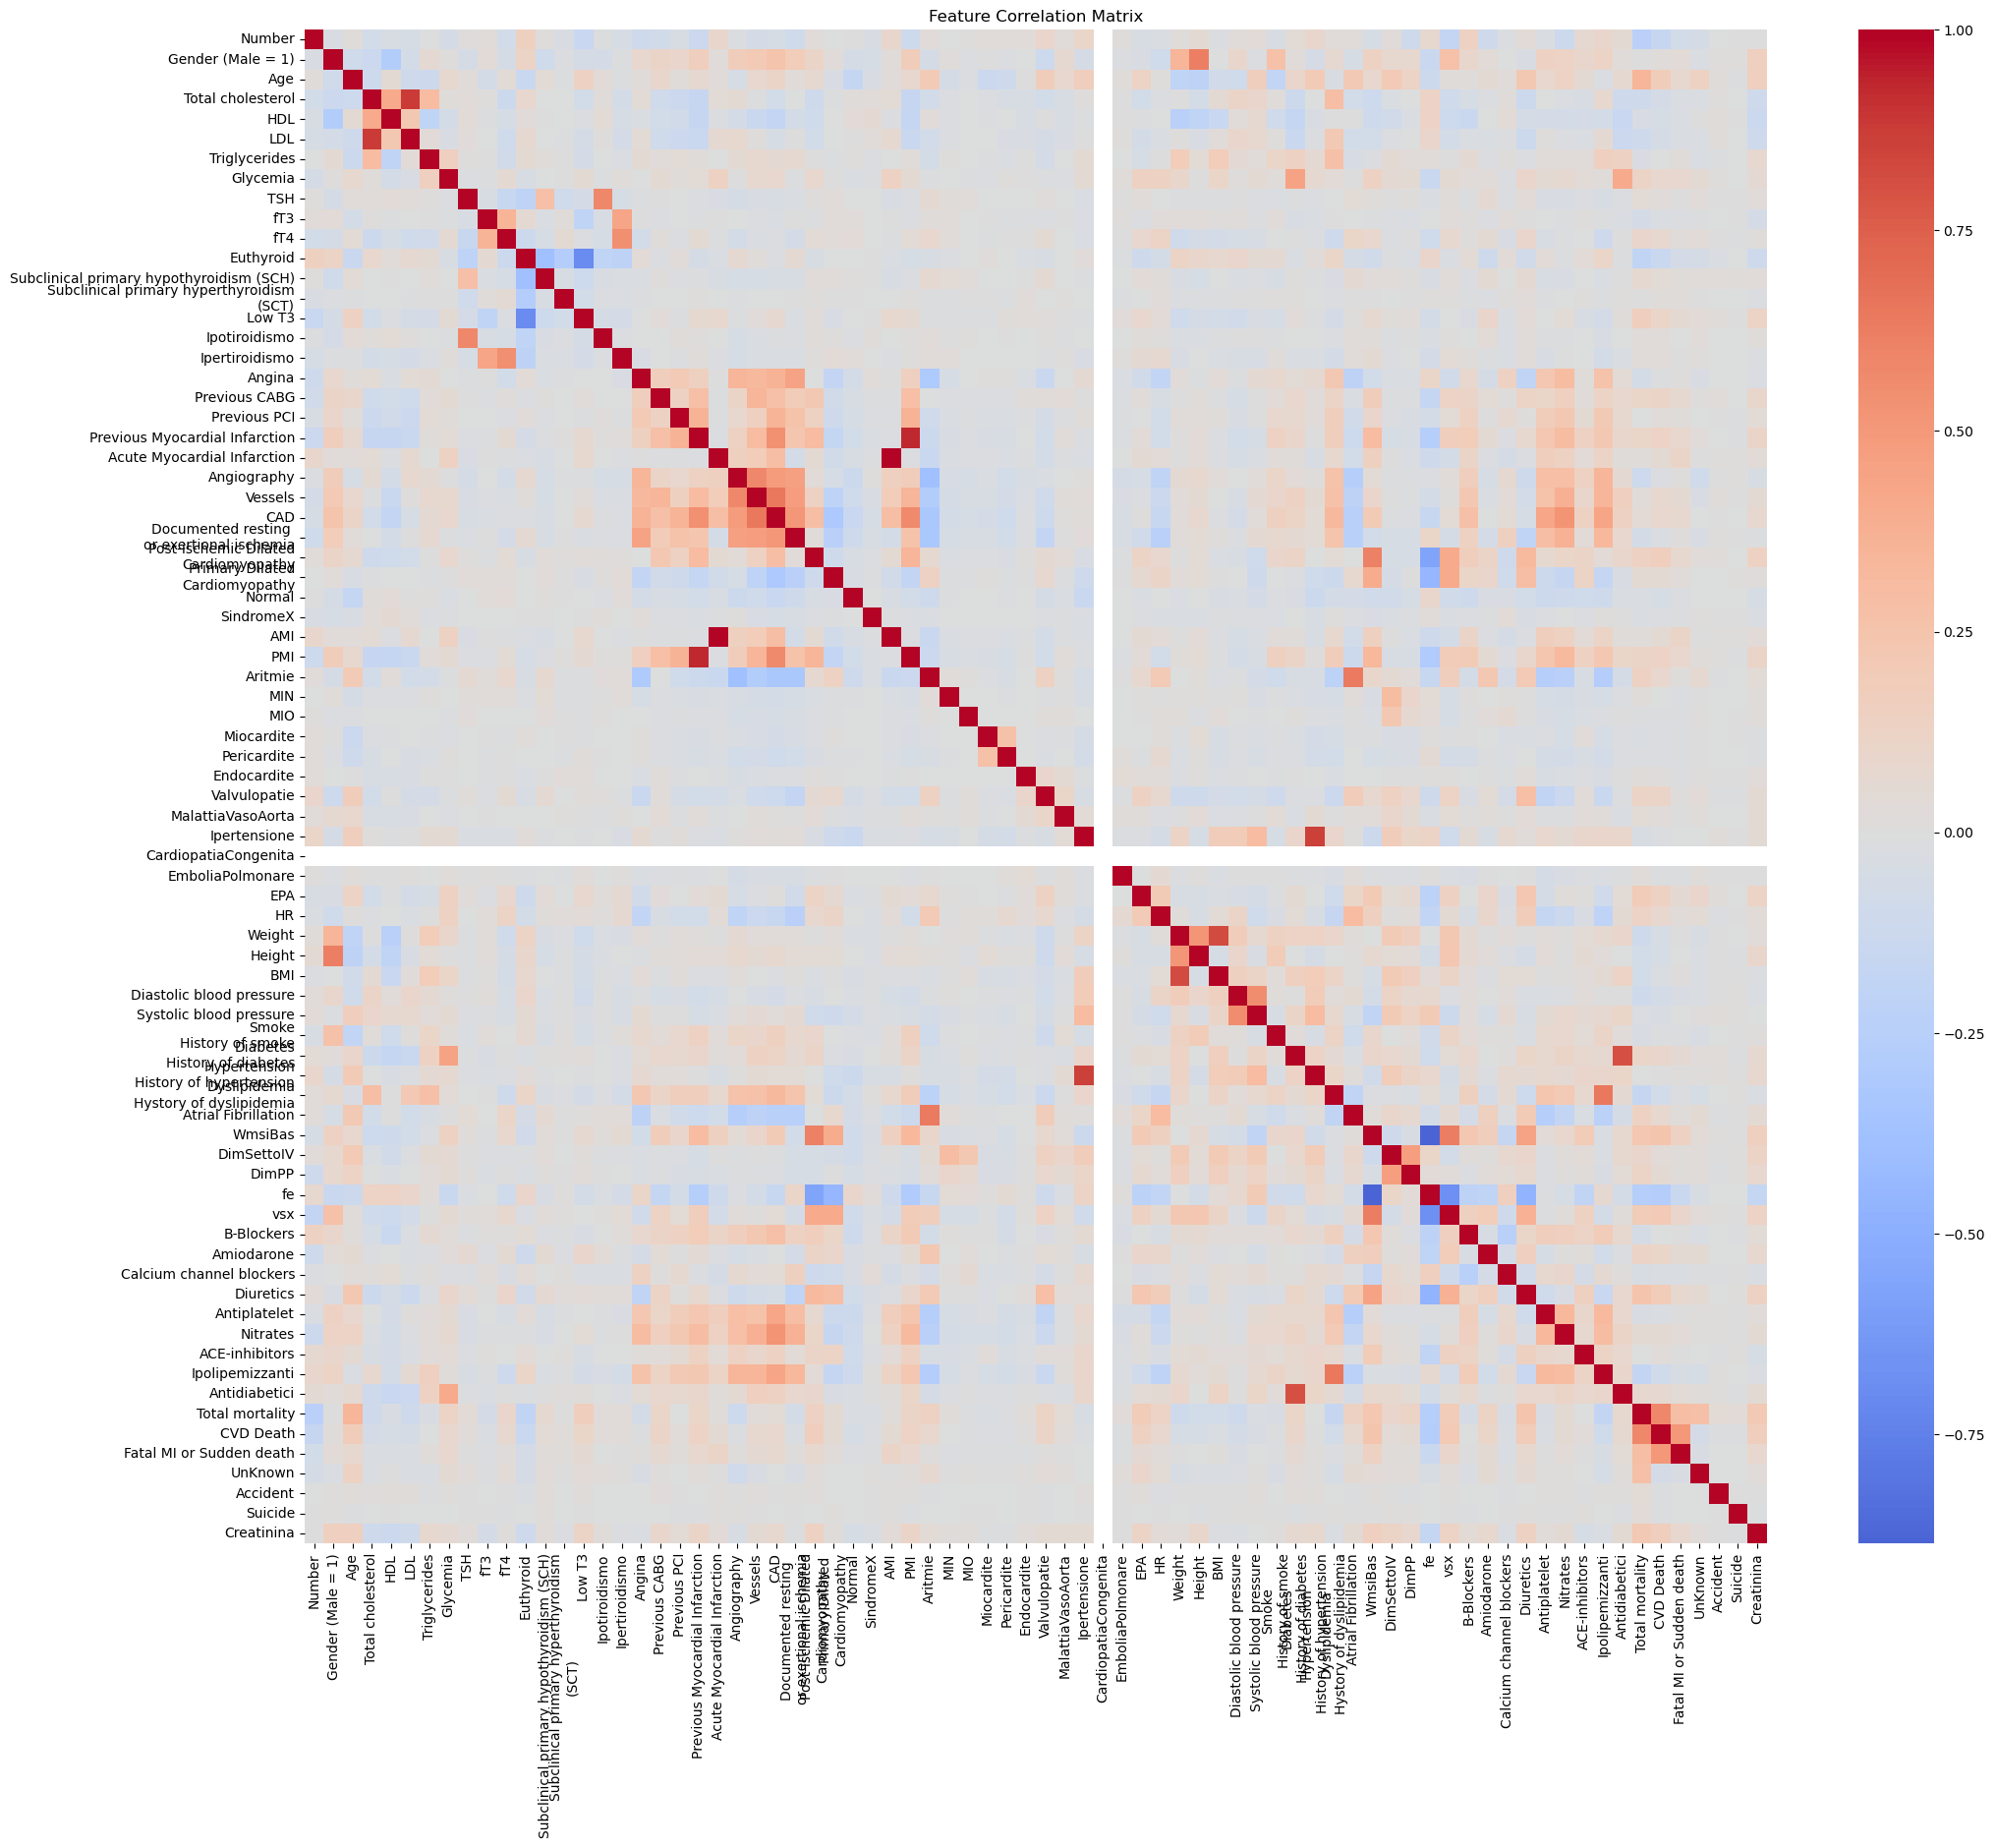

In [9]:
numeric_df = df_main.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [10]:
corr_threshold = 0.90

corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [column for column in upper.columns if any(upper[column] > corr_threshold)]

print("Highly correlated features:")
print(high_corr_features)

Highly correlated features:
['AMI', 'PMI']


In [11]:
print(df_main.describe())

            Number  Gender (Male = 1)          Age  Total cholesterol  \
count  8065.000000        8065.000000  8065.000000        7705.000000   
mean   4033.000000           0.658648    68.266614         183.750811   
min       1.000000           0.000000    13.851124          55.000000   
25%    2017.000000           0.000000    60.393258         153.000000   
50%    4033.000000           1.000000    69.904494         182.000000   
75%    6049.000000           1.000000    77.691011         210.000000   
max    8065.000000           1.000000   100.727528         605.000000   
std    2328.309294           0.474193    13.044562          44.423738   

               HDL          LDL  Triglycerides     Glycemia          TSH  \
count  7455.000000  7433.000000    7627.000000  7651.000000  8065.000000   
mean     42.325017   116.262855     123.750229   108.277480     2.133385   
min       6.000000    13.000000       9.000000     1.000000     0.010000   
25%      34.000000    91.000000      7

In [12]:
print(df_main["Documented resting \nor exertional ischemia"].nlargest(5))
df_main.loc[8143, "Documented resting \nor exertional ischemia"] = 1
print(df_main["Documented resting \nor exertional ischemia"].nlargest(5))

8143    5311.0
0          1.0
2          1.0
3          1.0
4          1.0
Name: Documented resting \nor exertional ischemia, dtype: float64
0    1.0
2    1.0
3    1.0
4    1.0
5    1.0
Name: Documented resting \nor exertional ischemia, dtype: float64


### Checking consistency of dataset

In [13]:
df_main = df_main.dropna(subset=['Number'])

df_main['Data prelievo'] = pd.to_datetime(df_main['Data prelievo'])
df_main['Follow Up Data'] = pd.to_datetime(df_main['Follow Up Data'])

print((df_main['Data prelievo'] <= df_main['Follow Up Data']).all())

True


In [14]:
violations = df_main[
    ((df_main["Total mortality"] == 0) & (df_main["Data of death"].notna())) |
    ((df_main["Total mortality"] != 0) & (df_main["Data of death"].isna()))
]

print(violations["Total mortality"])
print(violations["Data of death"])

df_main.loc[7285, "Total mortality"] = 1
df_main.loc[7285, "UnKnown"] = 1

print(df_main.iloc[7285][["Total mortality", "UnKnown"]])

7285    0.0
Name: Total mortality, dtype: float64
7285   2012-10-11
Name: Data of death, dtype: datetime64[ns]
Total mortality    1.0
UnKnown            1.0
Name: 7285, dtype: object


# Feature importance analysis

### Transform data to time to event and binary event


In [15]:
df_main["Follow Up Data"] = (
    df_main["Follow Up Data"] - df_main["Data prelievo"]
).dt.days

df_main["Data of death"] = (
    df_main["Data of death"] - df_main["Data prelievo"]
).dt.days
df_main["Data of death"] = df_main["Data of death"].fillna(0)


target = ["CABG " ,"Non Fatal AMI (Follow-Up)","Ictus","PCI"]

for t in target:
    df_main[t+"_event"] = df_main[t].notna().astype(int)

    df_main[t] = (
        df_main[t] - df_main["Data prelievo"]
    ).dt.days

    df_main[t] = df_main[t].fillna(0)

print(df_main.info())
print(df_main.head())



<class 'pandas.core.frame.DataFrame'>
Index: 8065 entries, 0 to 8064
Data columns (total 89 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Number                                      8065 non-null   float64       
 1   Gender (Male = 1)                           8065 non-null   float64       
 2   Age                                         8065 non-null   float64       
 3   Total cholesterol                           7705 non-null   float64       
 4   HDL                                         7455 non-null   float64       
 5   LDL                                         7433 non-null   float64       
 6   Triglycerides                               7627 non-null   float64       
 7   Glycemia                                    7651 non-null   float64       
 8   TSH                                         8065 non-null   float64       
 9   fT3          

### Missing values

In [16]:
missing = df_main.isna().sum().sort_values(ascending=False)
missing_percent = (df_main.isna().mean()*100).sort_values(ascending=False)

missing_table = pd.concat([missing, missing_percent], axis=1)
missing_table.columns = ["Missing Values", "Percentage"]

print(missing_table.head(20))

                          Missing Values  Percentage
Cause of death                      5659   70.167390
Collected by                        5658   70.154991
vsx                                  710    8.803472
LDL                                  632    7.836330
HDL                                  610    7.563546
Creatinina                           596    7.389957
BMI                                  573    7.104774
Height                               496    6.150031
Triglycerides                        438    5.430874
Glycemia                             414    5.133292
Weight                               414    5.133292
Total cholesterol                    360    4.463732
DimPP                                345    4.277743
DimSettoIV                           324    4.017359
WmsiBas                              223    2.765034
Systolic blood pressure              161    1.996280
Diastolic blood pressure             161    1.996280
Antidiabetici                        131    1.

In [17]:
df_main = df_main.drop(columns=["Collected by", "Cause of death","CardiopatiaCongenita"])
print(df_main.shape)
df_main = df_main.dropna()
print(df_main.shape)

(8065, 86)
(6264, 86)


## Correlation

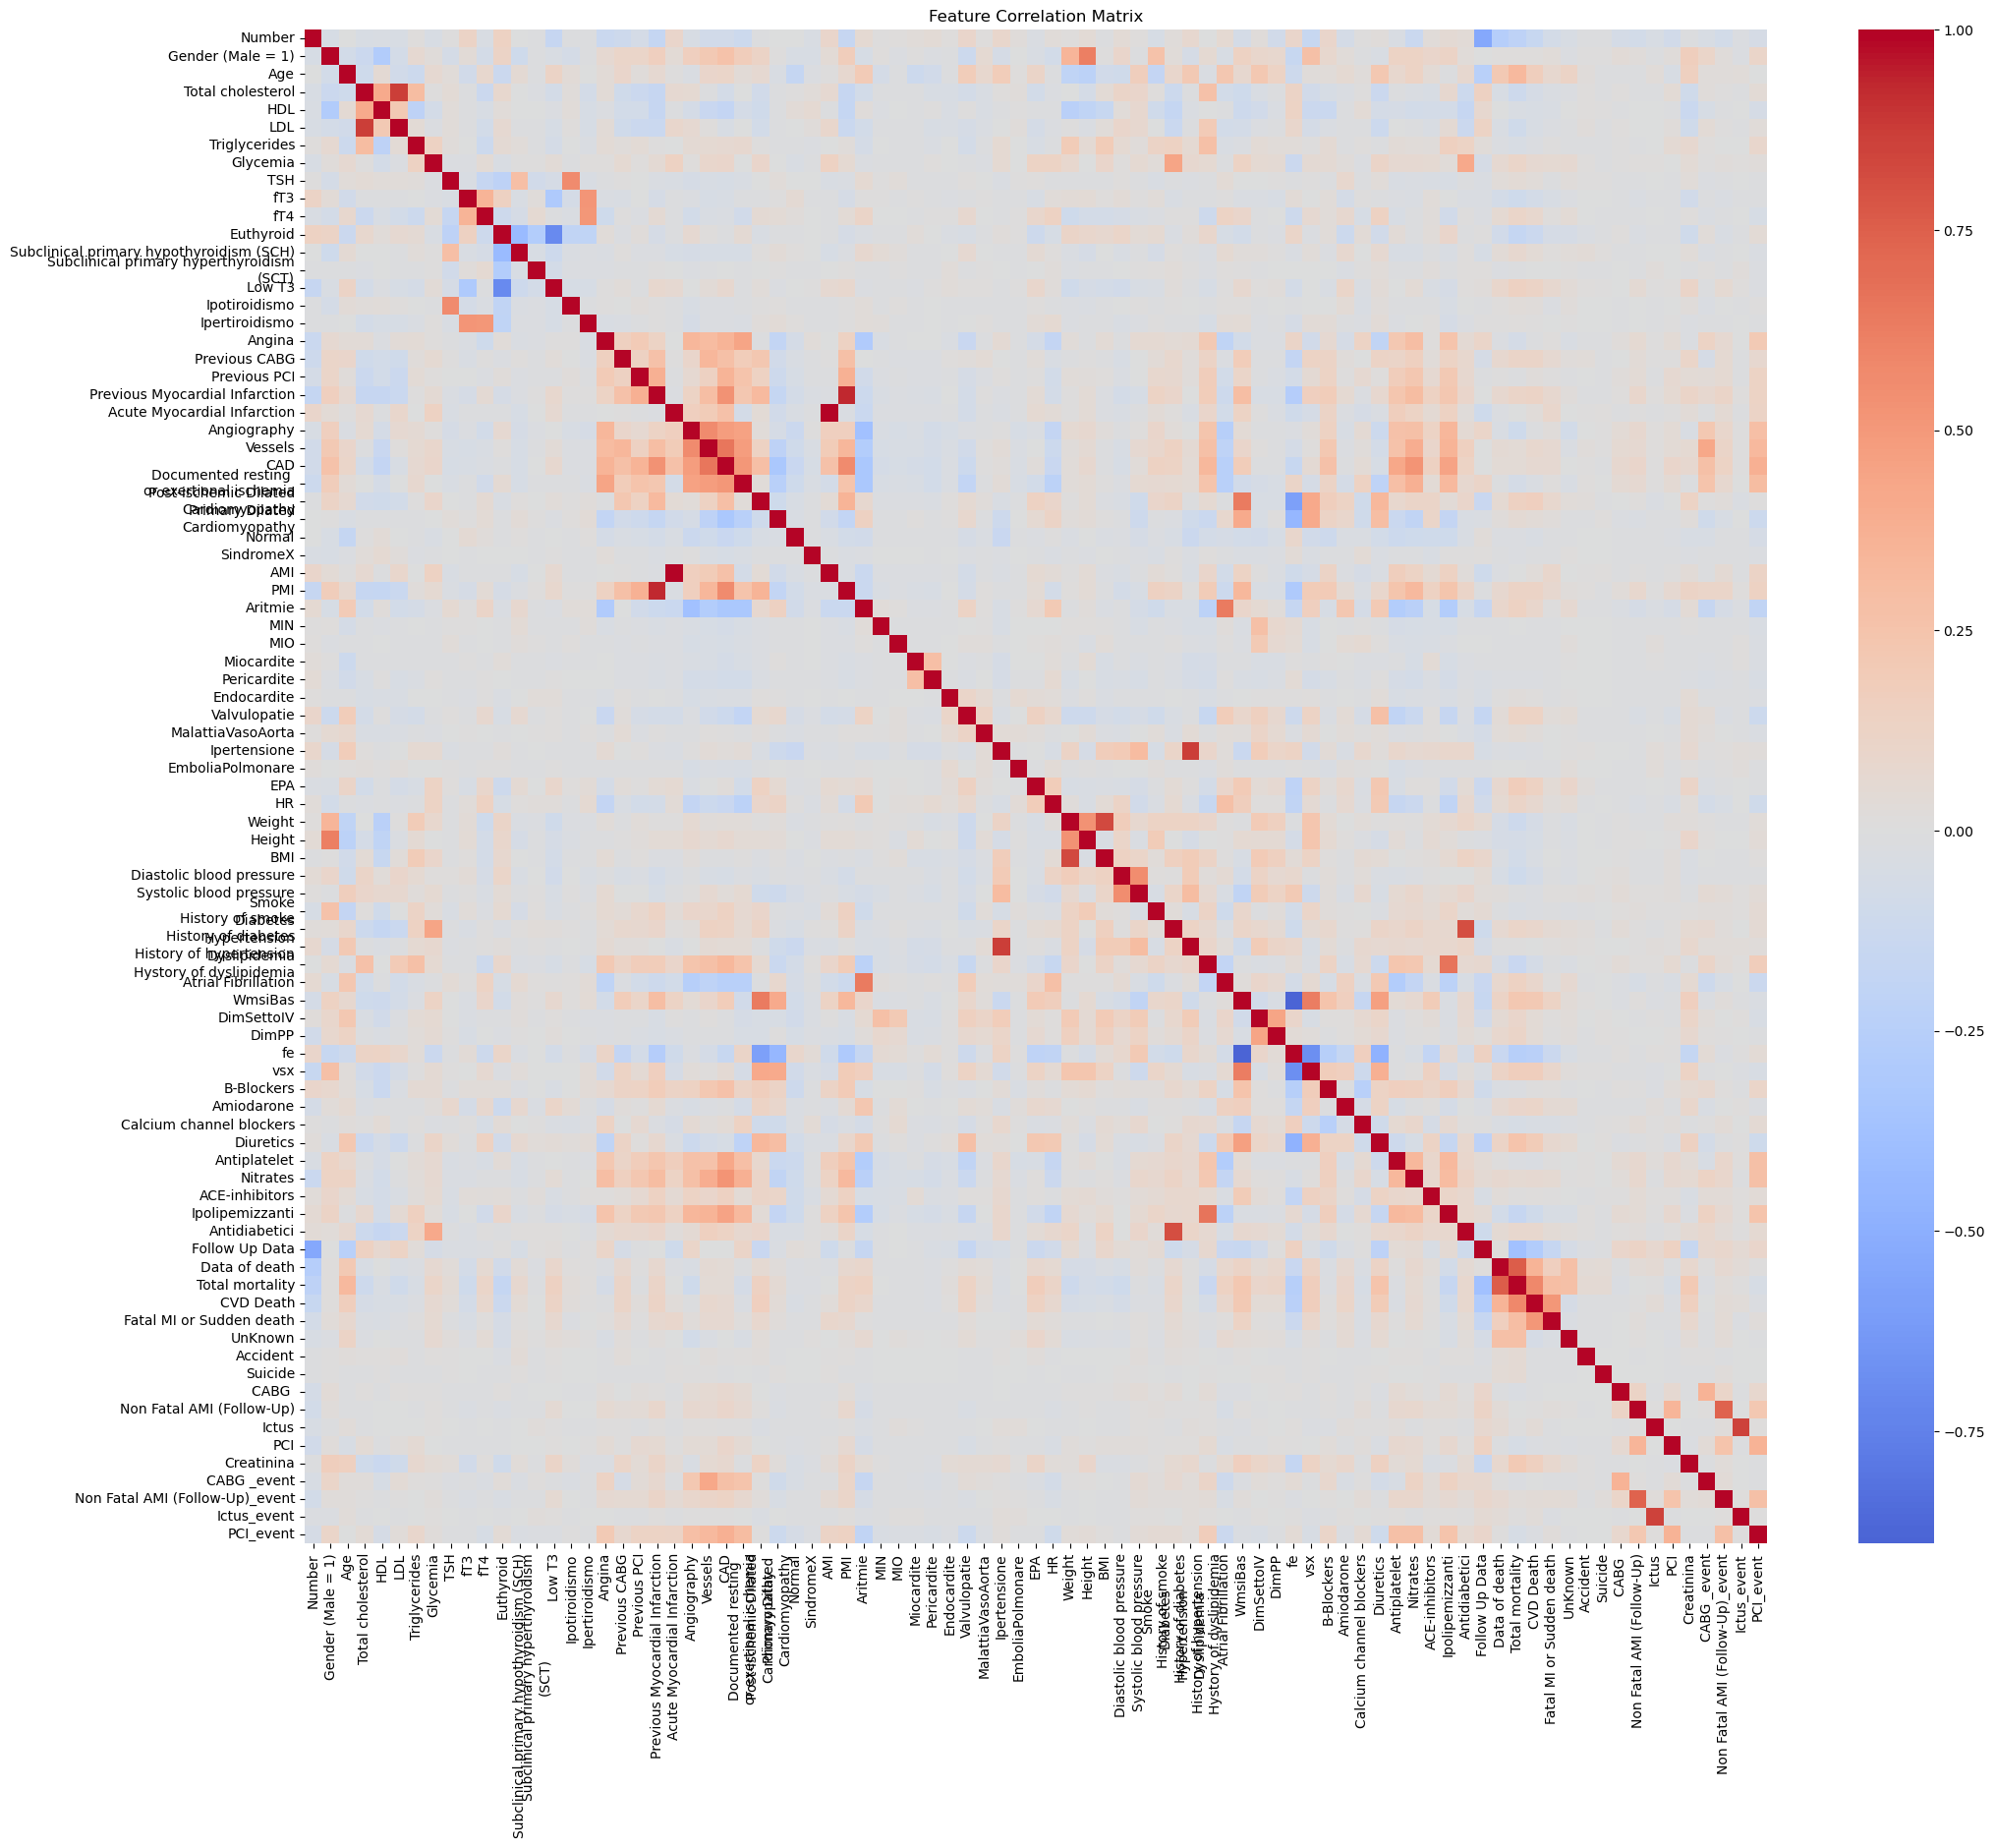

In [18]:
numeric_df = df_main.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [19]:
corr_threshold = 0.90

corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [column for column in upper.columns if any(upper[column] > corr_threshold)]

print("Highly correlated features:")
print(high_corr_features)

Highly correlated features:
['AMI', 'PMI']


# Time-to-event

### Mortality

In [20]:
# Split dataset into train, eval, and test sets

df_main['time'] = pd.qcut(df_main['Follow Up Data'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_main['stratum'] = df_main['Total mortality'].astype(str) + '_' + df_main['time'].astype(str)

df_mortality_train, df_tmp = train_test_split(
    df_main, test_size=0.2, random_state=42,
    stratify=df_main["stratum"]
)

df_mortality_eval, df_mortality_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_mortality_train, df_mortality_eval, df_mortality_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)

print(f"Train set: {len(df_mortality_train)} samples")
print(f"Eval set: {len(df_mortality_eval)} samples")
print(f"Test set: {len(df_mortality_test)} samples")



Train set: 5011 samples
Eval set: 626 samples
Test set: 627 samples


In [21]:
for name, split in [('Train', df_mortality_train), ('Val', df_mortality_eval), ('Test', df_mortality_test)]:
    rate = split['Total mortality'].mean()
    med_days = split['Follow Up Data'].median()
    print(f"{name}: event rate={rate:.2%}, median days={med_days:.0f}")

Train: event rate=26.04%, median days=2241
Val: event rate=26.04%, median days=2239
Test: event rate=26.16%, median days=2239


In [22]:
binary_cols = [
    col for col in df_mortality_train.columns
    if set(df_mortality_train[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'Total mortality', 'CVD Death', 'Fatal MI or Sudden death', 'UnKnown', 'Acc

In [23]:
# To avoid data leakage, we should not include features that are directly related to the target variable. 
# In this case, we will drop the columns that are related to mortality and cause of death, 
# as they would provide direct information about the outcome we are trying to predict.

cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo"]

tmp_train = df_mortality_train[cols_to_keep].copy()
tmp_test = df_mortality_test[cols_to_keep].copy()
tmp_eval = df_mortality_eval[cols_to_keep].copy()

df_mortality_train = df_mortality_train.drop(columns=cols_to_keep)
df_mortality_test = df_mortality_test.drop(columns=cols_to_keep)
df_mortality_eval = df_mortality_eval.drop(columns=cols_to_keep)

# Standardize continuous features
scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_mortality_train)

scaled_array_test = scaler.transform(df_mortality_test)
scaled_array_eval = scaler.transform(df_mortality_eval)

df_mortality_train = pd.DataFrame(scaled_array_train, columns=df_mortality_train.columns, index=df_mortality_train.index)
df_mortality_test = pd.DataFrame(scaled_array_test, columns=df_mortality_test.columns, index=df_mortality_test.index)
df_mortality_eval = pd.DataFrame(scaled_array_eval, columns=df_mortality_eval.columns, index=df_mortality_eval.index)

df_mortality_train = pd.concat([df_mortality_train, tmp_train], axis=1)
df_mortality_test = pd.concat([df_mortality_test, tmp_test], axis=1)
df_mortality_eval = pd.concat([df_mortality_eval, tmp_eval], axis=1)

columns_to_drop = [
    "Data of death",
    "Fatal MI or Sudden death",  
    "UnKnown", 
    "Accident",
    "Suicide",
    "Number",
    "CVD Death",
    "Data prelievo"]

df_mortality_train = df_mortality_train.drop(columns=columns_to_drop)
df_mortality_test = df_mortality_test.drop(columns=columns_to_drop)
df_mortality_eval = df_mortality_eval.drop(columns=columns_to_drop)

print(df_mortality_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5011 entries, 5683 to 1599
Data columns (total 78 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         5011 non-null   float64
 1   Total cholesterol                           5011 non-null   float64
 2   HDL                                         5011 non-null   float64
 3   LDL                                         5011 non-null   float64
 4   Triglycerides                               5011 non-null   float64
 5   Glycemia                                    5011 non-null   float64
 6   TSH                                         5011 non-null   float64
 7   fT3                                         5011 non-null   float64
 8   fT4                                         5011 non-null   float64
 9   Vessels                                     5011 non-null   float64
 10  HR            

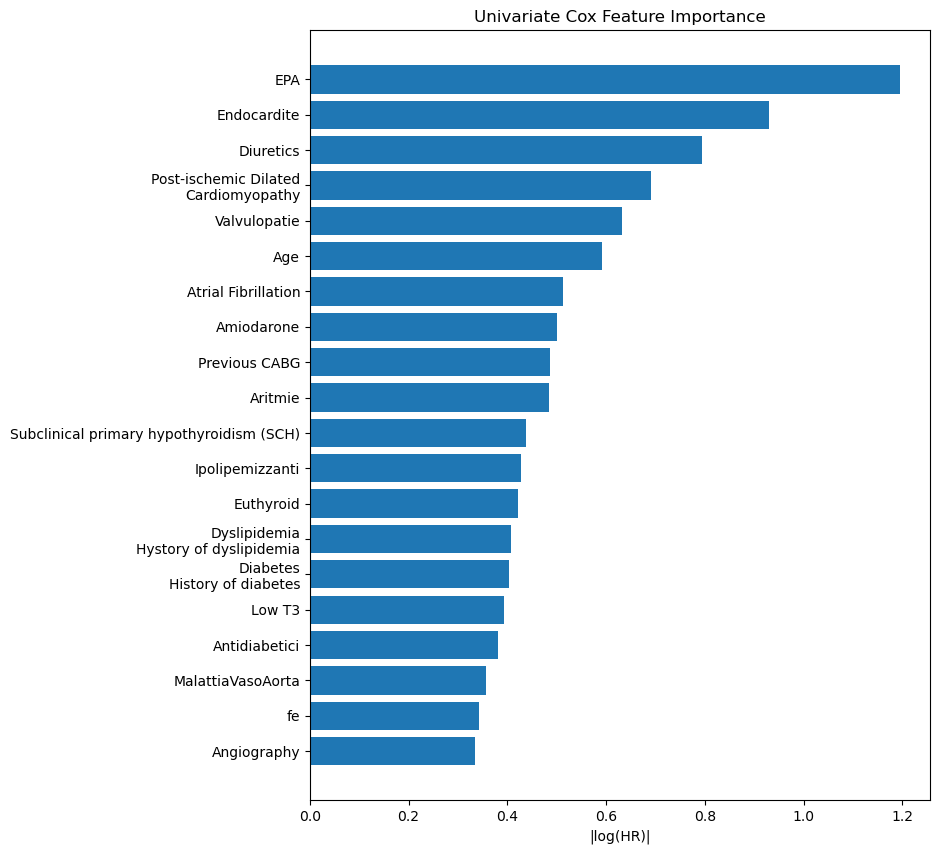

In [24]:
results = []
for c in df_mortality_train.columns: 
    if c not in ["Follow Up Data", "Total mortality"]:
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(
            df_mortality_train[[c,'Follow Up Data','Total mortality']], 
            duration_col='Follow Up Data', 
            event_col='Total mortality')
        coef = cph.summary.loc[c, "coef"]
        se = cph.summary.loc[c, "se(coef)"]
        p = cph.summary.loc[c, "p"]
        results.append({"feature": c, "coef": coef, "se": se, "p": p})

importance = pd.DataFrame(results)
importance_temp = importance[importance["p"] < 0.05].copy()

importance["abs_logHR"] = importance["coef"].abs()
importance = importance[importance["p"] < 0.05]
importance = importance.sort_values("abs_logHR", ascending=False).head(20)

plt.figure(figsize=(8,10))
plt.barh(importance["feature"], importance["abs_logHR"])
plt.gca().invert_yaxis()
plt.xlabel("|log(HR)|")
plt.title("Univariate Cox Feature Importance")
plt.show()

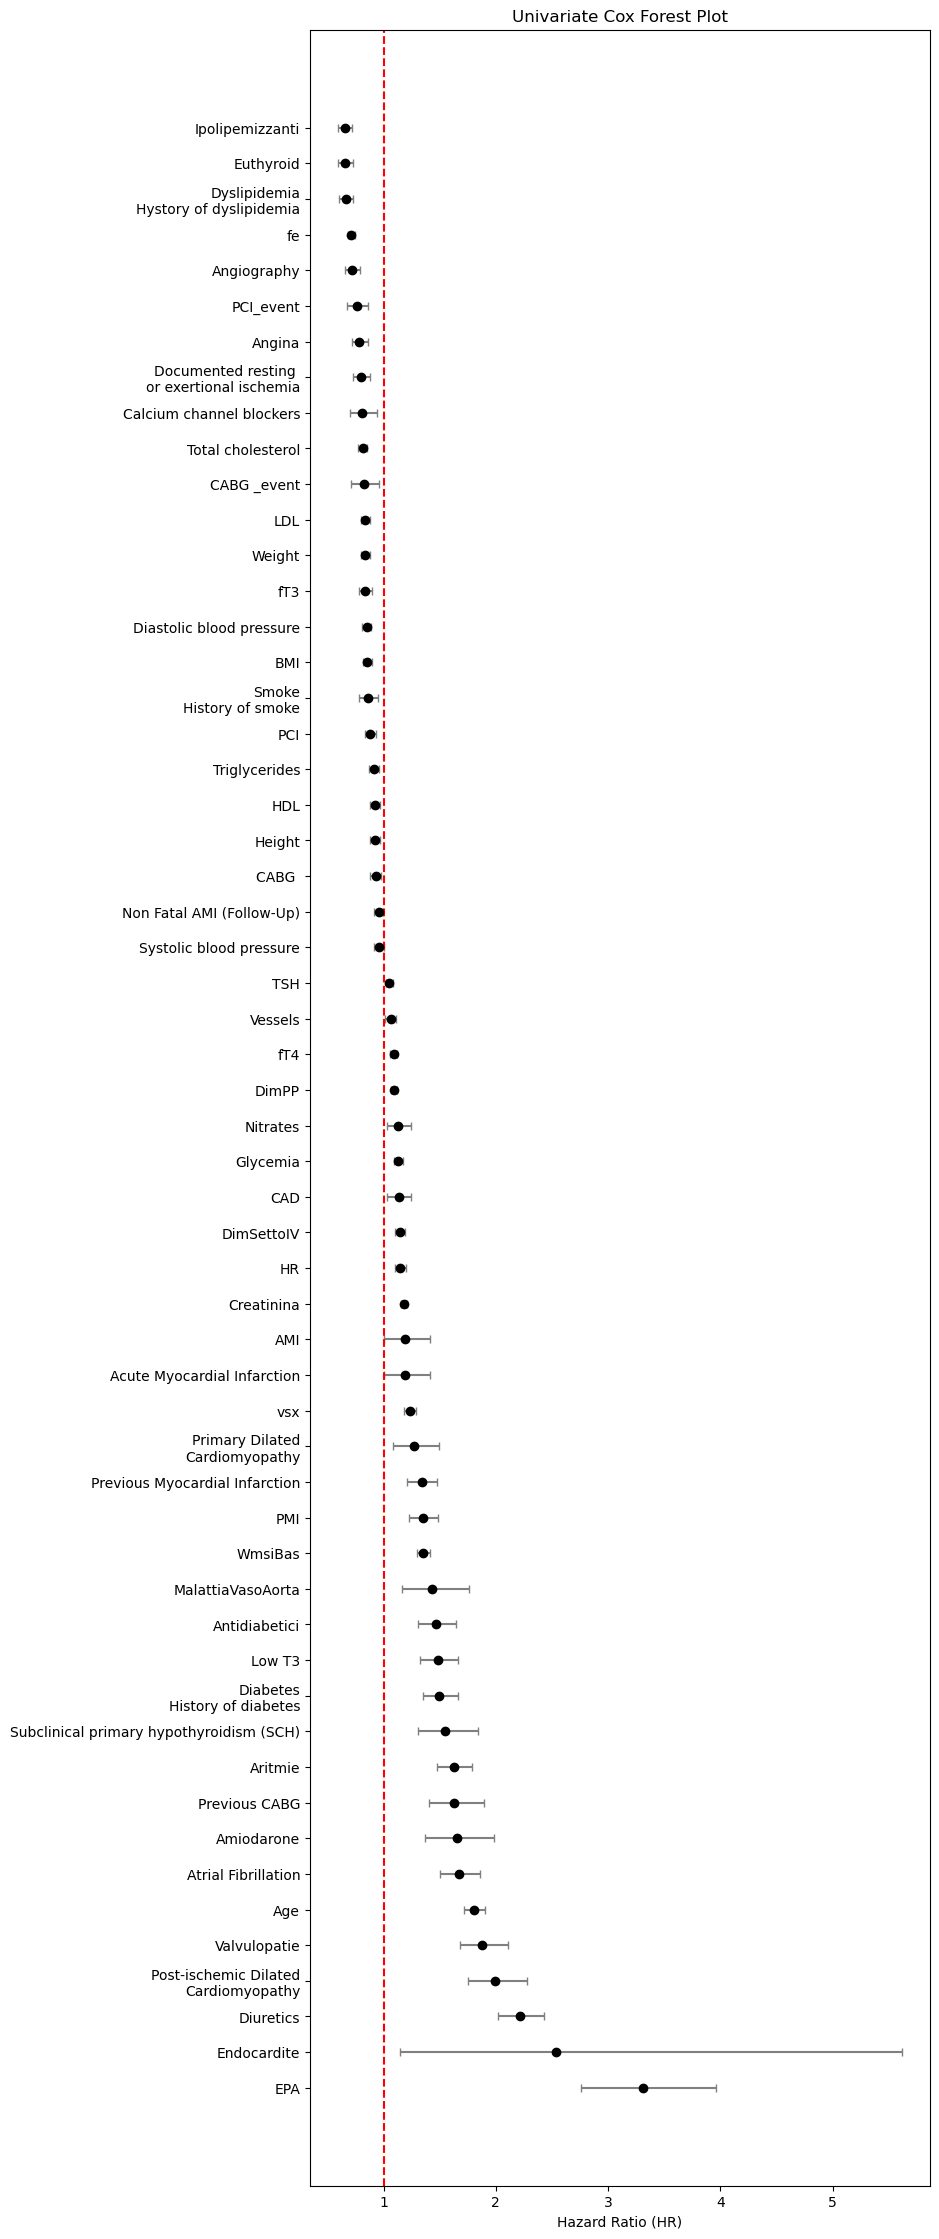

In [25]:
# Calculate HR and 95% CI
importance_temp["HR"] = np.exp(importance_temp["coef"])
importance_temp["HR_lower"] = np.exp(importance_temp["coef"] - 1.96*importance_temp["se"])
importance_temp["HR_upper"] = np.exp(importance_temp["coef"] + 1.96*importance_temp["se"])

# Sort by HR
importance_temp = importance_temp.sort_values("HR")

# Plot forest plot
plt.figure(figsize=(8, len(importance_temp)*0.5))
plt.errorbar(
    importance_temp["HR"],
    range(len(importance_temp)),
    xerr=[importance_temp["HR"] - importance_temp["HR_lower"], importance_temp["HR_upper"] - importance_temp["HR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)
plt.yticks(range(len(importance_temp)), importance_temp["feature"])
plt.axvline(x=1, color='red', linestyle='--')  # no-effect line
plt.xlabel("Hazard Ratio (HR)")
plt.title("Univariate Cox Forest Plot")
plt.gca().invert_yaxis()
plt.show()

Concordance Index: 0.8009858366202435


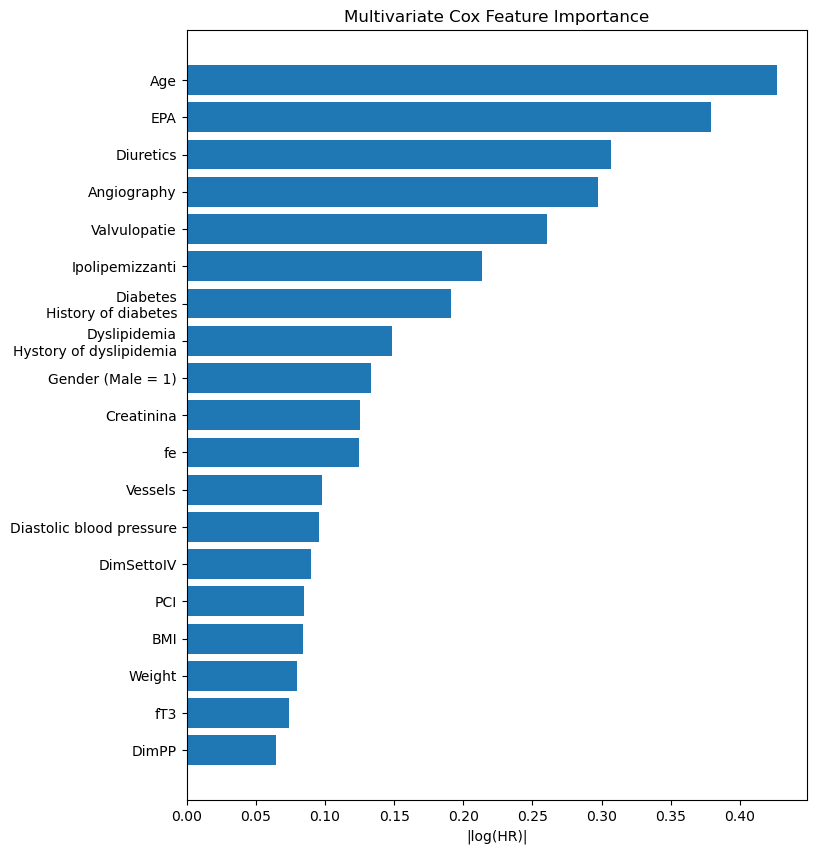

In [26]:
# Columns to use as covariates (exclude duration/event)
#covariates = [c for c in df_mortality.columns if c not in ['Data of death', 'Total mortality']]

# Fit multivariate Cox model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_mortality_train,#[covariates],# + ['Data of death', 'Total mortality']], 
        duration_col='Follow Up Data', 
        event_col='Total mortality')

print("Concordance Index:", cph.concordance_index_)

# Extract results
importance = cph.summary.reset_index()
importance.rename(columns={'index':'feature'}, inplace=True)

# Keep only significant features
importance = importance[importance["p"] < 0.05].copy()
importance_temp = importance.copy()

# Calculate |log(HR)|
importance["abs_logHR"] = importance["coef"].abs()

# Sort by |log(HR)| for plotting
importance = importance.sort_values("abs_logHR", ascending=False)  # top 20 if needed: .head(20)

# Plot |log(HR)|
plt.figure(figsize=(8,10))
plt.barh(importance["covariate"], importance["abs_logHR"])
plt.gca().invert_yaxis()
plt.xlabel("|log(HR)|")
plt.title("Multivariate Cox Feature Importance")
plt.show()

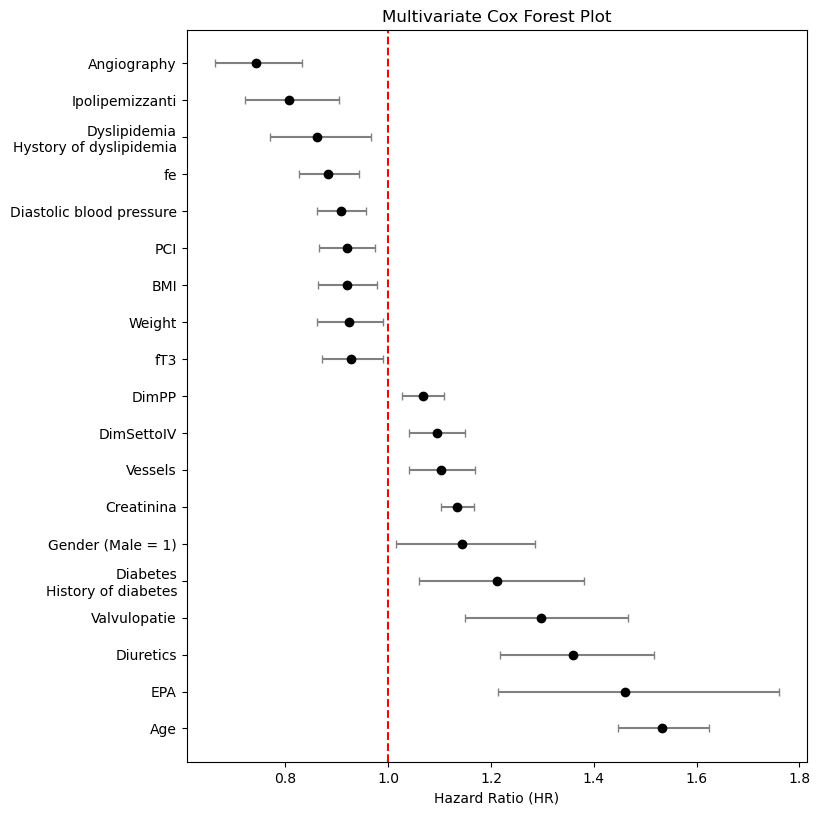

In [27]:
# Calculate HR and 95% CI
importance_temp["HR"] = np.exp(importance_temp["coef"])
importance_temp["HR_lower"] = np.exp(importance_temp["coef"] - 1.96*importance_temp["se(coef)"])
importance_temp["HR_upper"] = np.exp(importance_temp["coef"] + 1.96*importance_temp["se(coef)"])

# Sort by HR for plotting
importance_temp = importance_temp.sort_values("HR")

# Plot forest plot
plt.figure(figsize=(8, len(importance_temp)*0.5))
plt.errorbar(
    importance_temp["HR"],
    range(len(importance_temp)),
    xerr=[importance_temp["HR"] - importance_temp["HR_lower"], importance_temp["HR_upper"] - importance_temp["HR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)
plt.yticks(range(len(importance_temp)), importance_temp["covariate"])
plt.axvline(x=1, color='red', linestyle='--') 
plt.xlabel("Hazard Ratio (HR)")
plt.title("Multivariate Cox Forest Plot")
plt.gca().invert_yaxis()
plt.show()

##### DEEPSURV

In [28]:
# Assume 'T' = duration column, 'E' = event indicator
T_train = df_mortality_train["Follow Up Data"]         
E_train = df_mortality_train["Total mortality"]
X_train = df_mortality_train.drop(columns=["Follow Up Data", "Total mortality"])
T_test = df_mortality_test["Follow Up Data"]
E_test = df_mortality_test["Total mortality"]
X_test = df_mortality_test.drop(columns=["Follow Up Data", "Total mortality"])
T_eval = df_mortality_eval["Follow Up Data"]
E_eval = df_mortality_eval["Total mortality"]
X_eval = df_mortality_eval.drop(columns=["Follow Up Data", "Total mortality"])

# Convert DataFrames / Series to torch tensors for pycox
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
X_eval_tensor = torch.tensor(X_eval.values, dtype=torch.float32)
T_train_tensor = torch.tensor(T_train.values, dtype=torch.float32)
T_test_tensor = torch.tensor(T_test.values, dtype=torch.float32)
T_eval_tensor = torch.tensor(T_eval.values, dtype=torch.float32)
E_train_tensor = torch.tensor(E_train.values, dtype=torch.float32)
E_test_tensor = torch.tensor(E_test.values, dtype=torch.float32)
E_eval_tensor = torch.tensor(E_eval.values, dtype=torch.float32)


In [29]:
# Network definition
in_features = X_train.shape[1]
num_nodes = [32, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(in_features, num_nodes, 1, batch_norm=True, dropout=dropout, activation=nn.ReLU)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# DeepSurv model
model = CoxPH(net, tt.optim.AdamWR)

In [30]:
# Prepare dataset for pycox

# DeepSurv uses Cox PH loss, no need to transform labels
# But pycox allows easy handling of mini-batches

# Fit model
epochs = 100
batch_size = 128

model.fit(X_train_tensor, 
          (T_train_tensor, E_train_tensor), 
          batch_size, 
          epochs, 
          verbose=True,
          val_data=(X_eval_tensor, (T_eval_tensor, E_eval_tensor)))

/opt/miniconda3/lib/python3.13/site-packages/torchtuples/callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1728232383339/work/torch/csrc/utils/python_arg_parser.cpp:1581.)
  p.data = p.data.add(-weight_decay * eta, p.data)


0:	[0s / 0s],		train_loss: 4.1681,	val_loss: 5.6873
1:	[0s / 0s],		train_loss: 4.0188,	val_loss: 5.5649
2:	[0s / 0s],		train_loss: 3.9361,	val_loss: 5.5415
3:	[0s / 0s],		train_loss: 3.8976,	val_loss: 5.4714
4:	[0s / 0s],		train_loss: 3.8423,	val_loss: 5.4478
5:	[0s / 0s],		train_loss: 3.7968,	val_loss: 5.4388
6:	[0s / 0s],		train_loss: 3.7971,	val_loss: 5.4341
7:	[0s / 1s],		train_loss: 3.7701,	val_loss: 5.4262
8:	[0s / 1s],		train_loss: 3.7695,	val_loss: 5.4166
9:	[0s / 1s],		train_loss: 3.7507,	val_loss: 5.4106
10:	[0s / 1s],		train_loss: 3.7483,	val_loss: 5.4118
11:	[0s / 1s],		train_loss: 3.7378,	val_loss: 5.4140
12:	[0s / 1s],		train_loss: 3.6785,	val_loss: 5.4156
13:	[0s / 1s],		train_loss: 3.7104,	val_loss: 5.4145
14:	[0s / 1s],		train_loss: 3.7069,	val_loss: 5.4184
15:	[0s / 1s],		train_loss: 3.7142,	val_loss: 5.4185
16:	[0s / 2s],		train_loss: 3.6948,	val_loss: 5.4188
17:	[0s / 2s],		train_loss: 3.7253,	val_loss: 5.4265
18:	[0s / 2s],		train_loss: 3.6784,	val_loss: 5.4154
19:

In [31]:
# Concordance index
from pycox.evaluation import EvalSurv

# Predict log-risk for test set
risk_scores = model.predict(X_test_tensor)

# Convert to survival function
# For Cox, higher risk score = higher hazard
# EvalSurv can compute C-index

# Use Kaplan-Meier baseline estimate
baseline_hazard = model.compute_baseline_hazards()
surv = model.predict_surv_df(X_test_tensor)

# Concordance index
from pycox.evaluation import EvalSurv
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')
c_index = ev.concordance_td()
print("C-index:", c_index)

C-index: 0.7682829092366259


## Cardiovascular Mortality

In [32]:
df_cardiovascular = df_main.copy()
df_cardiovascular["Other deaths"] = df_cardiovascular["Total mortality"] - df_cardiovascular["CVD Death"]
df_cardiovascular["death"] = 0
df_cardiovascular.loc[df_cardiovascular["CVD Death"] == 1, "death"] = 1
df_cardiovascular.loc[df_cardiovascular["Other deaths"] == 1, "death"] = 2

In [33]:
df_cardiovascular["death"].value_counts()

death
0    4632
2     960
1     672
Name: count, dtype: int64

In [34]:
# Split dataset into train, eval, and test sets

df_cardiovascular['time'] = pd.qcut(df_cardiovascular['Follow Up Data'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_cardiovascular['stratum'] = df_cardiovascular['death'].astype(str) + '_' + df_cardiovascular['time'].astype(str)

df_cardiovascular_train, df_tmp = train_test_split(
    df_cardiovascular, test_size=0.2, random_state=42,
    stratify=df_cardiovascular["stratum"]
)

df_cardiovascular_eval, df_cardiovascular_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_cardiovascular_train, df_cardiovascular_eval, df_cardiovascular_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)

print(f"Train set: {len(df_cardiovascular_train)} samples")
print(f"Eval set: {len(df_cardiovascular_eval)} samples")
print(f"Test set: {len(df_cardiovascular_test)} samples")



Train set: 5011 samples
Eval set: 626 samples
Test set: 627 samples


In [35]:
for cause in [0, 1, 2]:
    print(f"\nEvent {cause}:")
    for name, split in [('Train', df_cardiovascular_train), ('Val', df_cardiovascular_eval), ('Test', df_cardiovascular_test)]:
        pct = (split['death'] == cause).mean()
        med = split.loc[split['death'] == cause, 'Follow Up Data'].median()
        print(f"  {name}: {pct:.2%} of samples, median days={med:.0f}")


Event 0:
  Train: 73.94% of samples, median days=2516
  Val: 73.96% of samples, median days=2472
  Test: 74.00% of samples, median days=2530

Event 1:
  Train: 10.74% of samples, median days=1090
  Val: 10.70% of samples, median days=1076
  Test: 10.69% of samples, median days=896

Event 2:
  Train: 15.33% of samples, median days=1587
  Val: 15.34% of samples, median days=1536
  Test: 15.31% of samples, median days=1570


In [36]:
binary_cols = [
    col for col in df_cardiovascular_train.columns
    if set(df_cardiovascular_train[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'Total mortality', 'CVD Death', 'Fatal MI or Sudden death', 'UnKnown', 'Acc

In [37]:
cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo","death"]

tmp_train = df_cardiovascular_train[cols_to_keep].copy()
tmp_eval = df_cardiovascular_eval[cols_to_keep].copy()
tmp_test = df_cardiovascular_test[cols_to_keep].copy()

df_cardiovascular_train = df_cardiovascular_train.drop(columns=cols_to_keep)
df_cardiovascular_eval = df_cardiovascular_eval.drop(columns=cols_to_keep)
df_cardiovascular_test = df_cardiovascular_test.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_cardiovascular_train)
scaled_array_eval = scaler.transform(df_cardiovascular_eval)
scaled_array_test = scaler.transform(df_cardiovascular_test)

df_cardiovascular_train = pd.DataFrame(scaled_array_train, columns=df_cardiovascular_train.columns, index=df_cardiovascular_train.index)
df_cardiovascular_eval = pd.DataFrame(scaled_array_eval, columns=df_cardiovascular_eval.columns, index=df_cardiovascular_eval.index)
df_cardiovascular_test = pd.DataFrame(scaled_array_test, columns=df_cardiovascular_test.columns, index=df_cardiovascular_test.index)

df_cardiovascular_train = pd.concat([df_cardiovascular_train, tmp_train], axis=1)
df_cardiovascular_eval = pd.concat([df_cardiovascular_eval, tmp_eval], axis=1)
df_cardiovascular_test = pd.concat([df_cardiovascular_test, tmp_test], axis=1)

cols_to_drop = [ "Fatal MI or Sudden death",  
                                            "UnKnown",
                                            "Total mortality", 
                                            "Accident",
                                            "Suicide",
                                            "Number",
                                            "Data prelievo",
                                            "CVD Death",
                                            "Other deaths",
                                            "Data of death"
                                             ]

df_cardiovascular_train = df_cardiovascular_train.drop(columns=cols_to_drop)
df_cardiovascular_eval = df_cardiovascular_eval.drop(columns=cols_to_drop)
df_cardiovascular_test = df_cardiovascular_test.drop(columns=cols_to_drop)

print(df_cardiovascular_train.info())
print(df_cardiovascular_train["death"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 5011 entries, 5869 to 5181
Data columns (total 78 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         5011 non-null   float64
 1   Total cholesterol                           5011 non-null   float64
 2   HDL                                         5011 non-null   float64
 3   LDL                                         5011 non-null   float64
 4   Triglycerides                               5011 non-null   float64
 5   Glycemia                                    5011 non-null   float64
 6   TSH                                         5011 non-null   float64
 7   fT3                                         5011 non-null   float64
 8   fT4                                         5011 non-null   float64
 9   Vessels                                     5011 non-null   float64
 10  HR            

In [38]:
causes = [1, 2]
models = {}

for cause in causes:
    df_temp = df_cardiovascular_train.copy()
    df_temp["death"] = (df_temp["death"] == cause).astype(int)

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        df_temp,
        duration_col="Follow Up Data",
        event_col='death'
    )
    models[cause] = cph

In [39]:
for model in models.values():
    print("Concordance Index:", model.concordance_index_)

Concordance Index: 0.8166616988658154
Concordance Index: 0.7950633999535508


                                       CV death  Other death    CV death p  \
covariate                                                                    
Age                                    1.239385     1.496001  1.016873e-09   
Vessels                                1.098636     1.029337  6.814074e-03   
Weight                                 0.937474     0.918941  8.316694e-02   
BMI                                    0.955205     0.908543  1.962236e-01   
Diastolic blood pressure               0.934424     0.936429  3.953391e-02   
WmsiBas                                1.094625     1.025632  1.285953e-02   
DimSettoIV                             1.082286     1.091381  1.490573e-02   
DimPP                                  1.043272     1.077089  1.854991e-01   
fe                                     0.866977     0.935563  1.306787e-04   
vsx                                    1.082737     1.004448  1.985027e-02   
PCI                                    0.947879     0.928089  1.

<Axes: xlabel='covariate'>

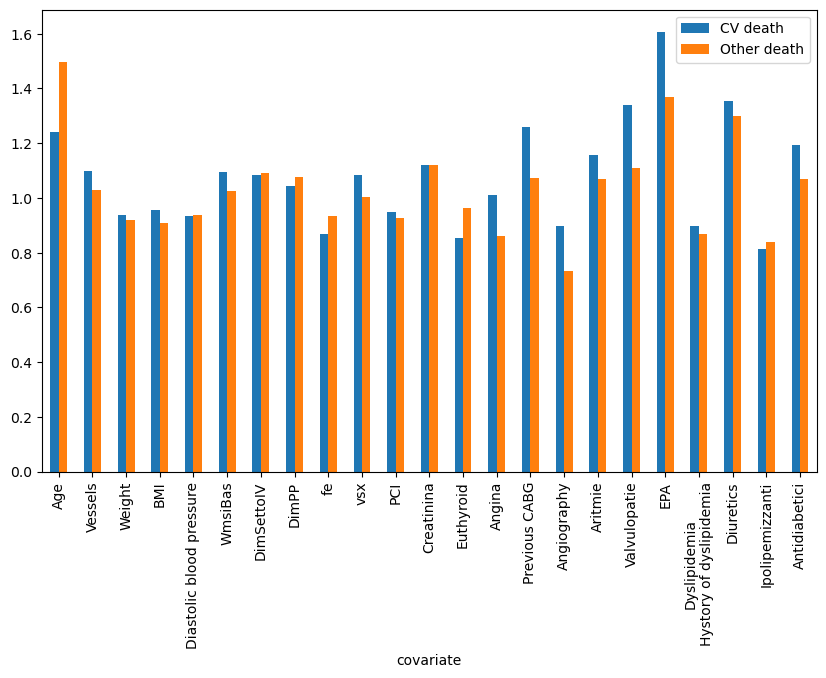

In [40]:
coef_cv = models[1].summary["exp(coef)"]
coef_other = models[2].summary["exp(coef)"]
p_cv = models[1].summary["p"]
p_other = models[2].summary["p"]

significant = (
    (p_cv < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "CV death": coef_cv,
    "Other death": coef_other,
    "CV death p": p_cv,
    "Other death p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["CV death","Other death"]].plot.bar(figsize=(10,6))

##### DEEPHIT

Network output nodes needed: 100
0:	[0s / 0s],		train_loss: 0.4969,	val_loss: 0.4848
1:	[0s / 0s],		train_loss: 0.4732,	val_loss: 0.4678
2:	[0s / 0s],		train_loss: 0.4605,	val_loss: 0.4652
3:	[0s / 0s],		train_loss: 0.4562,	val_loss: 0.4548
4:	[0s / 0s],		train_loss: 0.4351,	val_loss: 0.4481
5:	[0s / 1s],		train_loss: 0.4302,	val_loss: 0.4445
6:	[0s / 1s],		train_loss: 0.4275,	val_loss: 0.4447
7:	[0s / 1s],		train_loss: 0.4261,	val_loss: 0.4371
8:	[0s / 1s],		train_loss: 0.4200,	val_loss: 0.4331
9:	[0s / 1s],		train_loss: 0.4142,	val_loss: 0.4288
10:	[0s / 1s],		train_loss: 0.4082,	val_loss: 0.4270
11:	[0s / 2s],		train_loss: 0.3981,	val_loss: 0.4263
12:	[0s / 2s],		train_loss: 0.4011,	val_loss: 0.4253
13:	[0s / 2s],		train_loss: 0.3979,	val_loss: 0.4249
14:	[0s / 2s],		train_loss: 0.3944,	val_loss: 0.4263
15:	[0s / 2s],		train_loss: 0.3975,	val_loss: 0.4228
16:	[0s / 2s],		train_loss: 0.3922,	val_loss: 0.4219
17:	[0s / 3s],		train_loss: 0.3827,	val_loss: 0.4212
18:	[0s / 3s],		train_l

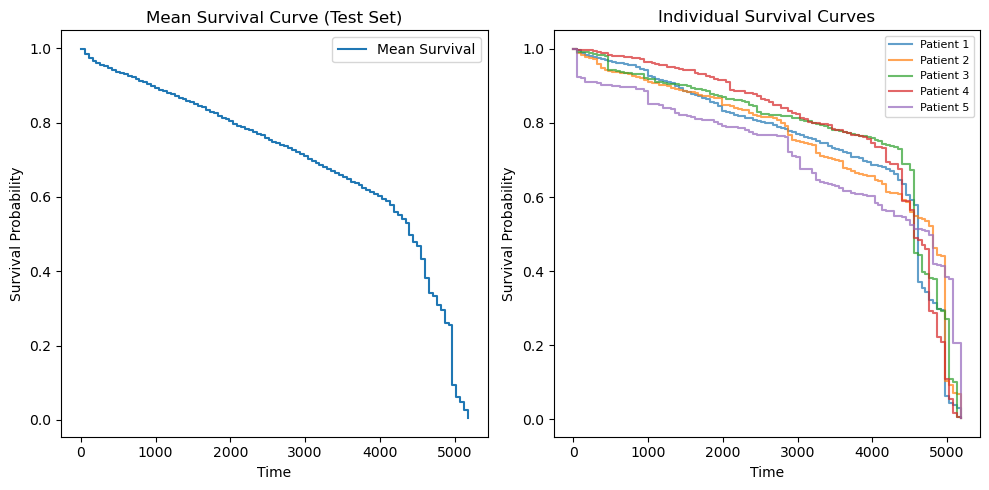

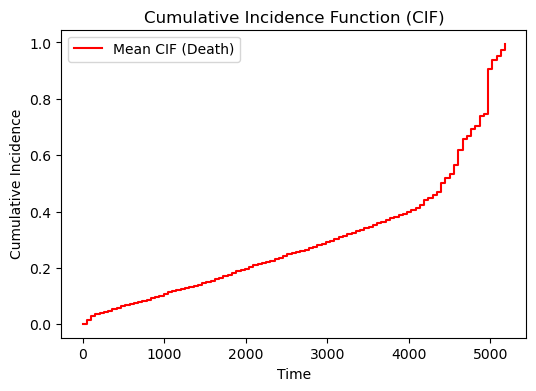


C-index: 0.7892


In [41]:
# ------------------------------
# 1. Load and prepare data
# ------------------------------

# Assume 'T' = duration column, 'E' = event indicator
T_train = df_cardiovascular_train["Follow Up Data"] 
T_test = df_cardiovascular_test["Follow Up Data"] 
T_eval = df_cardiovascular_eval["Follow Up Data"]         
E_train = df_cardiovascular_train["death"]
E_test = df_cardiovascular_test["death"]
E_eval = df_cardiovascular_eval["death"]
X_train = df_cardiovascular_train.drop(columns=["Follow Up Data", "death"])
X_test = df_cardiovascular_test.drop(columns=["Follow Up Data", "death"])
X_eval = df_cardiovascular_eval.drop(columns=["Follow Up Data", "death"])

X_train_np = X_train.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
X_eval_np = X_eval.values.astype('float32')

# ------------------------------
# 2. Define DeepHit network
# ------------------------------

# Choose number of discrete time intervals
num_durations = 100  # can also try 200

labtrans = LabTransDiscreteTime(num_durations)

# Fit and transform train labels
y_train = labtrans.fit_transform(T_train.values, E_train.values) 
y_test = labtrans.transform(T_test.values, E_test.values)
y_eval = labtrans.transform(T_eval.values, E_eval.values)

# Now the number of output nodes = labtrans.out_features
out_features = labtrans.out_features
print("Network output nodes needed:", out_features)

in_features = X_train.shape[1]
num_nodes = [64, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(
    in_features, 
    num_nodes, 
    out_features = out_features ,  # output nodes for discretized times
    batch_norm=True, 
    dropout=dropout, 
    activation=torch.nn.ReLU
)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# Define DeepHit model
model = DeepHitSingle(net, tt.optim.AdamWR, duration_index=labtrans.cuts)  # duration_index will be inferred automatically

# ------------------------------
# 3. Train model
# ------------------------------
epochs = 50
batch_size = 128

log = model.fit(
    X_train_np, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
    val_data = (X_eval_np, y_eval)
)

# ------------------------------
# 4. Predict survival functions
# ------------------------------
surv = model.predict_surv_df(X_test_np)  # returns survival probability over discretized times

# ------------------------------
# 5. Evaluate model
# ------------------------------
# For competing risks, we evaluate CIF for each event type
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')

# Concordance index (overall)
c_index = ev.concordance_td()
print("C-index:", c_index)

# ------------------------------
# 6. Plot survival curves
# ------------------------------
times = surv.index.values

# Option A: Plot mean survival curve across all test patients
mean_surv = surv.mean(axis=1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.step(times, mean_surv, where='post', label='Mean Survival')
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Mean Survival Curve (Test Set)")
plt.legend()

# Option B: Plot a few individual patient survival curves
plt.subplot(1, 2, 2)
for i in range(min(5, surv.shape[1])):  # plot first 5 patients
    plt.step(times, surv.iloc[:, i], where='post', alpha=0.7, label=f"Patient {i+1}")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Individual Survival Curves")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Plot CIF (1 - Survival)
# ------------------------------
plt.figure(figsize=(6, 4))
mean_cif = 1 - mean_surv
plt.step(times, mean_cif, where='post', color='red', label='Mean CIF (Death)')
plt.xlabel("Time")
plt.ylabel("Cumulative Incidence")
plt.title("Cumulative Incidence Function (CIF)")
plt.legend()
plt.show()

print(f"\nC-index: {c_index:.4f}")

### Time to Myocardial Infarction

In [42]:
df_MI = df_main.copy()
df_MI["MI_event"] = df_MI[["Fatal MI or Sudden death", "Non Fatal AMI (Follow-Up)_event"]].max(axis=1)
df_MI["Other events"] = df_MI["Total mortality"] - df_MI["MI_event"]
df_MI["events"] = 0
df_MI.loc[df_MI["MI_event"] == 1, "events"] = 1
df_MI.loc[df_MI["Other events"] == 1, "events"] = 2

In [43]:
df_MI["events"].value_counts()

events
0    4477
2    1386
1     401
Name: count, dtype: int64

In [44]:
conditions = [
    df_main["Non Fatal AMI (Follow-Up)_event"] == 1,
    df_main["Fatal MI or Sudden death"] == 1
]

choices = [
    df_main["Non Fatal AMI (Follow-Up)"],
    df_main["Data of death"]
]

df_MI["MI_date"] = np.select(
    conditions,
    choices,
    default=df_main["Follow Up Data"]
)

In [45]:
# Split dataset into train, eval, and test sets

df_MI['time'] = pd.qcut(df_MI['MI_date'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_MI['stratum'] = df_MI['events'].astype(str) + '_' + df_MI['time'].astype(str)

df_MI_train, df_tmp = train_test_split(
    df_MI, test_size=0.2, random_state=42,
    stratify=df_cardiovascular["stratum"]
)

df_MI_eval, df_MI_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_MI_train, df_MI_eval, df_MI_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)

print(f"Train set: {len(df_MI_train)} samples")
print(f"Eval set: {len(df_MI_eval)} samples")
print(f"Test set: {len(df_MI_test)} samples")



Train set: 5011 samples
Eval set: 626 samples
Test set: 627 samples


In [46]:
binary_cols = [
    col for col in df_MI_train.columns
    if set(df_MI[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'Total mortality', 'CVD Death', 'Fatal MI or Sudden death', 'UnKnown', 'Acc

In [47]:
cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo", "events","MI_date"]

tmp_train = df_MI_train[cols_to_keep].copy()
tmp_test = df_MI_test[cols_to_keep].copy()
tmp_eval = df_MI_eval[cols_to_keep].copy()

df_MI_train = df_MI_train.drop(columns=cols_to_keep)
df_MI_test = df_MI_test.drop(columns=cols_to_keep)
df_MI_eval = df_MI_eval.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_MI_train)
scaled_array_test = scaler.transform(df_MI_test)
scaled_array_eval = scaler.transform(df_MI_eval)

df_MI_train = pd.DataFrame(scaled_array_train, columns=df_MI_train.columns, index=df_MI_train.index)
df_MI_test = pd.DataFrame(scaled_array_test, columns=df_MI_test.columns, index=df_MI_test.index)
df_MI_eval = pd.DataFrame(scaled_array_eval, columns=df_MI_eval.columns, index=df_MI_eval.index)

df_MI_train = pd.concat([df_MI_train, tmp_train], axis=1)
df_MI_test = pd.concat([df_MI_test, tmp_test], axis=1)
df_MI_eval = pd.concat([df_MI_eval, tmp_eval], axis=1)

cols_to_drop = [    "Fatal MI or Sudden death",  
                                "UnKnown",
                                "Total mortality", 
                                "Accident",
                                "Suicide",
                                "Number",
                                "Data prelievo",
                                "CVD Death",
                                "Other events",
                                "Data of death",
                                "Non Fatal AMI (Follow-Up)_event",
                                "Non Fatal AMI (Follow-Up)",
                                "Follow Up Data",
                                "MI_event"
                                ]
df_MI_train = df_MI_train.drop(columns=cols_to_drop)
df_MI_test = df_MI_test.drop(columns=cols_to_drop)
df_MI_eval = df_MI_eval.drop(columns=cols_to_drop)

df_MI_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5011 entries, 5869 to 5181
Data columns (total 76 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         5011 non-null   float64
 1   Total cholesterol                           5011 non-null   float64
 2   HDL                                         5011 non-null   float64
 3   LDL                                         5011 non-null   float64
 4   Triglycerides                               5011 non-null   float64
 5   Glycemia                                    5011 non-null   float64
 6   TSH                                         5011 non-null   float64
 7   fT3                                         5011 non-null   float64
 8   fT4                                         5011 non-null   float64
 9   Vessels                                     5011 non-null   float64
 10  HR            

In [48]:
causes = [1, 2]
models = {}

for cause in causes:
    df_temp = df_MI_train.copy()
    df_temp["events"] = (df_temp["events"] == cause).astype(int)

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        df_temp,
        duration_col="MI_date",
        event_col='events'
    )
    models[cause] = cph

In [49]:
for model in models.values():
    print("Concordance Index:", model.concordance_index_)

Concordance Index: 0.7884960389578963
Concordance Index: 0.8015228558226808


                                       MI event  Other event    MI event p  \
covariate                                                                    
Age                                    1.096570     1.516683  1.465579e-02   
fT3                                    0.960620     0.928082  3.139130e-01   
fT4                                    0.998029     1.063250  9.576028e-01   
Vessels                                1.070145     1.078641  6.689590e-02   
HR                                     0.989465     1.049918  7.709036e-01   
Weight                                 0.975281     0.916917  5.183572e-01   
BMI                                    0.984927     0.911259  6.884216e-01   
Diastolic blood pressure               0.978436     0.926226  5.443599e-01   
DimSettoIV                             1.033572     1.102250  3.740833e-01   
DimPP                                  1.029037     1.071359  4.498173e-01   
fe                                     0.923947     0.895639  4.

<Axes: xlabel='covariate'>

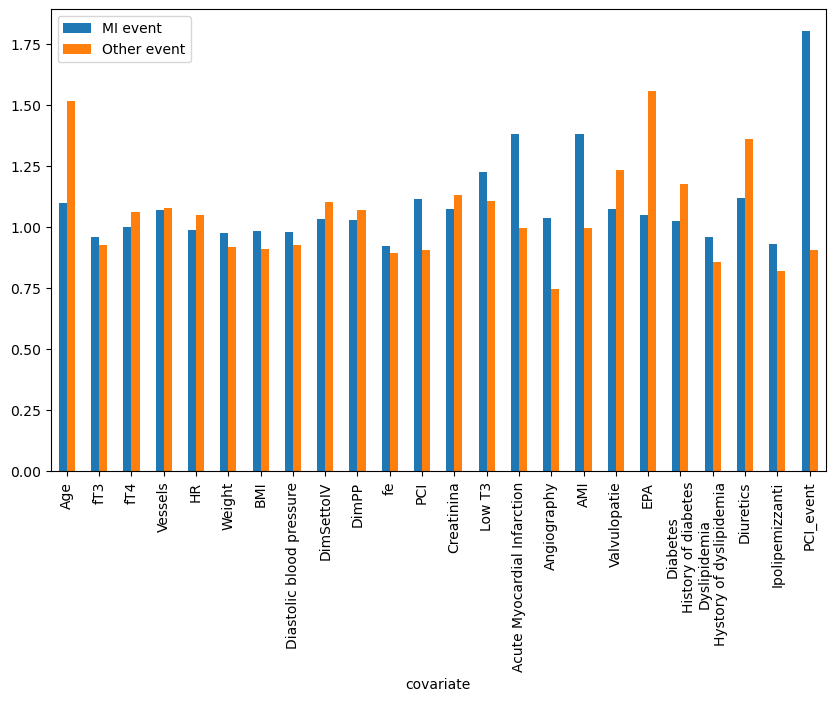

In [50]:
coef_MI = models[1].summary["exp(coef)"]
coef_other = models[2].summary["exp(coef)"]
p_MI = models[1].summary["p"]
p_other = models[2].summary["p"]

significant = (
    (p_MI < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "MI event": coef_MI,
    "Other event": coef_other,
    "MI event p": p_MI,
    "Other event p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["MI event","Other event"]].plot.bar(figsize=(10,6))

Network output nodes needed: 100
0:	[0s / 0s],		train_loss: 0.5263,	val_loss: 0.5061
1:	[0s / 0s],		train_loss: 0.5034,	val_loss: 0.4863
2:	[0s / 0s],		train_loss: 0.4921,	val_loss: 0.4830
3:	[0s / 0s],		train_loss: 0.4848,	val_loss: 0.4711
4:	[0s / 1s],		train_loss: 0.4731,	val_loss: 0.4662
5:	[0s / 1s],		train_loss: 0.4662,	val_loss: 0.4629
6:	[0s / 1s],		train_loss: 0.4641,	val_loss: 0.4623
7:	[0s / 1s],		train_loss: 0.4614,	val_loss: 0.4569
8:	[0s / 1s],		train_loss: 0.4559,	val_loss: 0.4532
9:	[0s / 2s],		train_loss: 0.4543,	val_loss: 0.4503
10:	[0s / 2s],		train_loss: 0.4488,	val_loss: 0.4490
11:	[0s / 2s],		train_loss: 0.4374,	val_loss: 0.4492
12:	[0s / 2s],		train_loss: 0.4450,	val_loss: 0.4473
13:	[0s / 2s],		train_loss: 0.4343,	val_loss: 0.4478
14:	[0s / 2s],		train_loss: 0.4382,	val_loss: 0.4483
15:	[0s / 3s],		train_loss: 0.4335,	val_loss: 0.4461
16:	[0s / 3s],		train_loss: 0.4325,	val_loss: 0.4438
17:	[0s / 3s],		train_loss: 0.4303,	val_loss: 0.4418
18:	[0s / 3s],		train_l

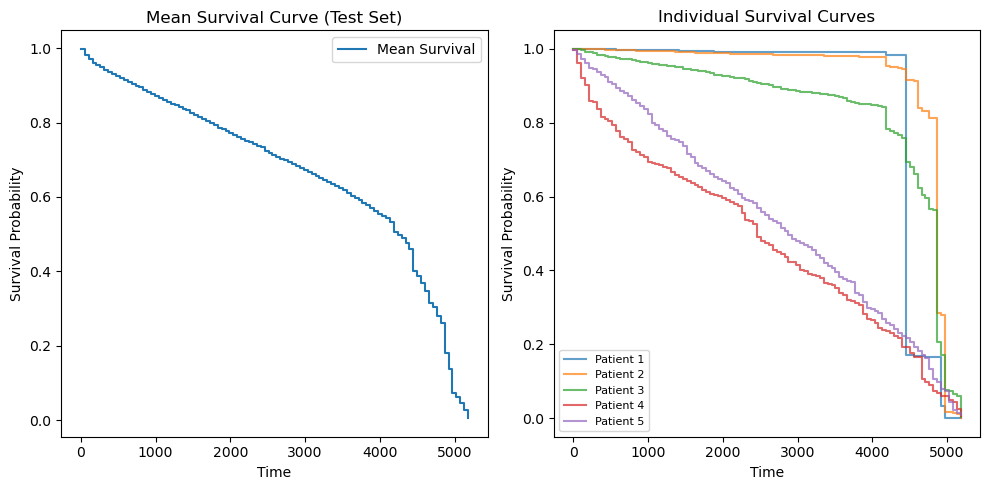

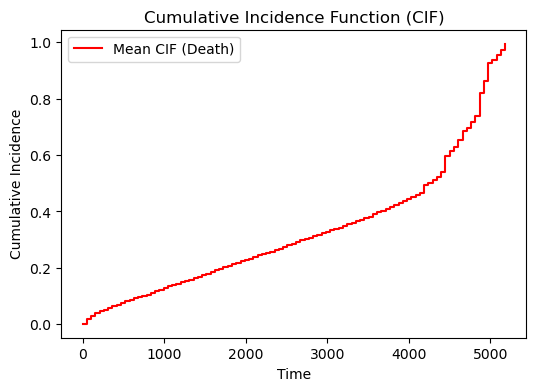


C-index: 0.7196


In [51]:
# ------------------------------
# 1. Load and prepare data
# ------------------------------

# Assume 'T' = duration column, 'E' = event indicator
T_train = df_MI_train["MI_date"]  
T_test = df_MI_test["MI_date"]  
T_eval = df_MI_eval["MI_date"]         
E_train = df_MI_train["events"]
E_test = df_MI_test["events"]
E_eval = df_MI_eval["events"]
X_train = df_MI_train.drop(columns=["MI_date", "events"])
X_test = df_MI_test.drop(columns=["MI_date", "events"])
X_eval = df_MI_eval.drop(columns=["MI_date", "events"]) 

X_train_np = X_train.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
X_eval_np  = X_eval.values.astype('float32')
 
# ------------------------------
# 2. Define DeepHit network
# ------------------------------

# Choose number of discrete time intervals
num_durations = 100  # can also try 200

labtrans = LabTransDiscreteTime(num_durations)

# Fit and transform train labels
y_train = labtrans.fit_transform(T_train.values, E_train.values) 
y_test = labtrans.transform(T_test.values, E_test.values)
y_eval = labtrans.transform(T_eval.values, E_eval.values)

# Now the number of output nodes = labtrans.out_features
out_features = labtrans.out_features
print("Network output nodes needed:", out_features)

in_features = X_train.shape[1]
num_nodes = [64, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(
    in_features, 
    num_nodes, 
    out_features = out_features ,  # output nodes for discretized times
    batch_norm=True, 
    dropout=dropout, 
    activation=torch.nn.ReLU
)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# Define DeepHit model
model = DeepHitSingle(net, tt.optim.AdamWR, duration_index=labtrans.cuts)  # duration_index will be inferred automatically

# ------------------------------
# 3. Train model
# ------------------------------
epochs = 50
batch_size = 128

log = model.fit(
    X_train_np, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
    val_data= (X_eval_np, y_eval )
)

# ------------------------------
# 4. Predict survival functions
# ------------------------------
surv = model.predict_surv_df(X_test_np)  # returns survival probability over discretized times

# ------------------------------
# 5. Evaluate model
# ------------------------------
# For competing risks, we evaluate CIF for each event type
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')

# Concordance index (overall)
c_index = ev.concordance_td()
print("C-index:", c_index)

# ------------------------------
# 6. Plot survival curves
# ------------------------------
times = surv.index.values

# Option A: Plot mean survival curve across all test patients
mean_surv = surv.mean(axis=1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.step(times, mean_surv, where='post', label='Mean Survival')
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Mean Survival Curve (Test Set)")
plt.legend()

# Option B: Plot a few individual patient survival curves
plt.subplot(1, 2, 2)
for i in range(min(5, surv.shape[1])):  # plot first 5 patients
    plt.step(times, surv.iloc[:, i], where='post', alpha=0.7, label=f"Patient {i+1}")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Individual Survival Curves")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Plot CIF (1 - Survival)
# ------------------------------
plt.figure(figsize=(6, 4))
mean_cif = 1 - mean_surv
plt.step(times, mean_cif, where='post', color='red', label='Mean CIF (Death)')
plt.xlabel("Time")
plt.ylabel("Cumulative Incidence")
plt.title("Cumulative Incidence Function (CIF)")
plt.legend()
plt.show()

print(f"\nC-index: {c_index:.4f}")

### Time to stroke

In [52]:
df_stroke = df_main.copy()
df_stroke["events"] = 0
df_stroke.loc[df_stroke["Ictus_event"] == 1, "events"] = 1
df_stroke.loc[df_stroke["Total mortality"] == 1, "events"] = 2

In [53]:
df_stroke["Ictus_date"] = np.where( 
    df_stroke["Ictus_event"] == 1,
    df_stroke["Ictus"], 
    df_stroke["Follow Up Data"] )

In [54]:
# Split dataset into train, eval, and test sets

df_stroke['time'] = pd.qcut(df_stroke['Ictus_date'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_stroke['stratum'] = df_stroke['events'].astype(str) + '_' + df_stroke['time'].astype(str)

df_stroke_train, df_tmp = train_test_split(
    df_stroke, test_size=0.3, random_state=42,
    stratify=df_stroke["stratum"]
)

df_stroke_eval, df_stroke_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_stroke_train, df_stroke_eval, df_stroke_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)

print(f"Train set: {len(df_stroke_train)} samples")
print(f"Eval set: {len(df_stroke_eval)} samples")
print(f"Test set: {len(df_stroke_test)} samples")



Train set: 4384 samples
Eval set: 940 samples
Test set: 940 samples


In [55]:
binary_cols = [
    col for col in df_stroke_train.columns
    if set(df_stroke_train[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'Total mortality', 'CVD Death', 'Fatal MI or Sudden death', 'UnKnown', 'Acc

In [56]:
cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo","Ictus_date", "events"]

tmp_train = df_stroke_train[cols_to_keep].copy()
tmp_test = df_stroke_test[cols_to_keep].copy()
tmp_eval = df_stroke_eval[cols_to_keep].copy()

df_stroke_train = df_stroke_train.drop(columns=cols_to_keep)
df_stroke_test = df_stroke_test.drop(columns=cols_to_keep)
df_stroke_eval = df_stroke_eval.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_stroke_train)
scaled_array_test = scaler.transform(df_stroke_test)
scaled_array_eval = scaler.transform(df_stroke_eval)

df_stroke_train = pd.DataFrame(scaled_array_train, columns=df_stroke_train.columns, index=df_stroke_train.index)
df_stroke_test = pd.DataFrame(scaled_array_test, columns=df_stroke_test.columns, index=df_stroke_test.index)
df_stroke_eval = pd.DataFrame(scaled_array_eval, columns=df_stroke_eval.columns, index=df_stroke_eval.index)


df_stroke_train = pd.concat([df_stroke_train, tmp_train], axis=1)
df_stroke_test = pd.concat([df_stroke_test, tmp_test], axis=1)
df_stroke_eval = pd.concat([df_stroke_eval, tmp_eval], axis=1)

cols_to_drop = [    "Fatal MI or Sudden death",  
                    "UnKnown",
                    "Total mortality", 
                    "Accident",
                    "Suicide",
                    "Number",
                    "Data prelievo",
                    "CVD Death",
                    "Data of death",
                    "Non Fatal AMI (Follow-Up)_event",
                    "Non Fatal AMI (Follow-Up)",
                    "Follow Up Data",
                    "Ictus_event",
                    "Ictus"]

df_stroke_train = df_stroke_train.drop(columns=cols_to_drop)
df_stroke_test = df_stroke_test.drop(columns=cols_to_drop)
df_stroke_eval = df_stroke_eval.drop(columns=cols_to_drop)

print(df_stroke_train.info())
print(df_stroke_train["events"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 4384 entries, 6358 to 6724
Data columns (total 74 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         4384 non-null   float64
 1   Total cholesterol                           4384 non-null   float64
 2   HDL                                         4384 non-null   float64
 3   LDL                                         4384 non-null   float64
 4   Triglycerides                               4384 non-null   float64
 5   Glycemia                                    4384 non-null   float64
 6   TSH                                         4384 non-null   float64
 7   fT3                                         4384 non-null   float64
 8   fT4                                         4384 non-null   float64
 9   Vessels                                     4384 non-null   float64
 10  HR            

In [57]:
causes = [1, 2]
models = {}

for cause in causes:
    df_temp = df_stroke_train.copy()
    df_temp["events"] = (df_temp["events"] == cause).astype(int)

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        df_temp,
        duration_col="Ictus_date",
        event_col='events'
    )
    models[cause] = cph

In [58]:
for model in models.values():
    print("Concordance Index:", model.concordance_index_)

Concordance Index: 0.7770926790287136
Concordance Index: 0.8063990850027709


                                       Stroke event  Other event  \
covariate                                                          
Age                                        1.022923     1.528303   
Vessels                                    1.004813     1.108444   
Weight                                     0.992680     0.922360   
Height                                     1.014601     0.934860   
Diastolic blood pressure                   1.003326     0.906071   
DimSettoIV                                 1.022447     1.103623   
DimPP                                      0.998497     1.078249   
fe                                         1.017362     0.891572   
vsx                                        0.974897     1.071716   
PCI                                        1.000227     0.910658   
Creatinina                                 1.001316     1.136522   
Gender (Male = 1)                          0.976865     1.157546   
Angiography                                0.993

<Axes: xlabel='covariate'>

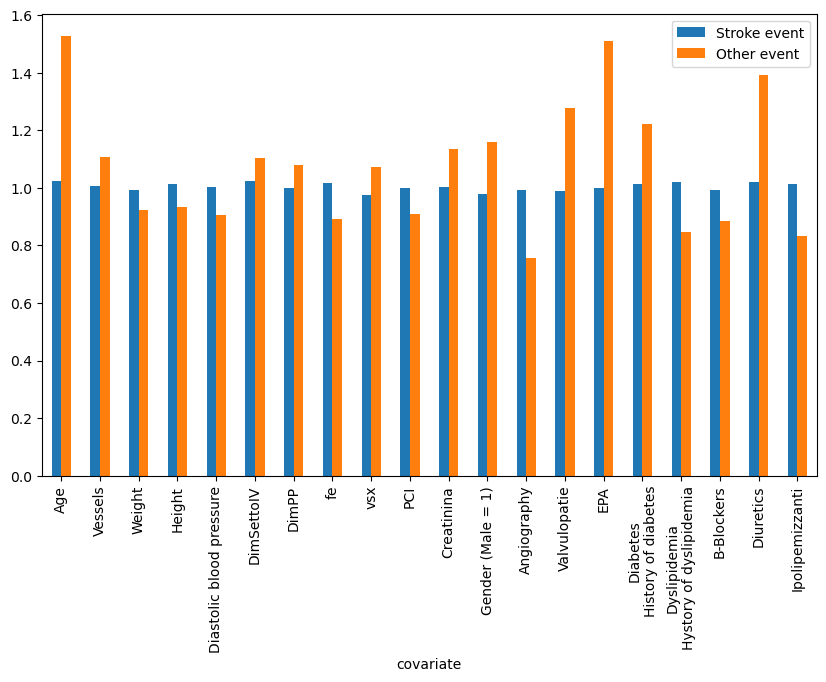

In [59]:
coef_stroke = models[1].summary["exp(coef)"]
coef_other = models[2].summary["exp(coef)"]
p_stroke = models[1].summary["p"]
p_other = models[2].summary["p"]

significant = (
    (p_stroke < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "Stroke event": coef_stroke,
    "Other event": coef_other,
    "Stroke event p": p_stroke,
    "Other event p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["Stroke event","Other event"]].plot.bar(figsize=(10,6))

Network output nodes needed: 100
0:	[0s / 0s],		train_loss: 0.5072,	val_loss: 0.4943
1:	[0s / 0s],		train_loss: 0.4872,	val_loss: 0.4782
2:	[0s / 0s],		train_loss: 0.4713,	val_loss: 0.4758
3:	[0s / 0s],		train_loss: 0.4675,	val_loss: 0.4657
4:	[0s / 0s],		train_loss: 0.4540,	val_loss: 0.4620
5:	[0s / 0s],		train_loss: 0.4449,	val_loss: 0.4603
6:	[0s / 1s],		train_loss: 0.4459,	val_loss: 0.4602
7:	[0s / 1s],		train_loss: 0.4384,	val_loss: 0.4561
8:	[0s / 1s],		train_loss: 0.4292,	val_loss: 0.4536
9:	[0s / 1s],		train_loss: 0.4228,	val_loss: 0.4537
10:	[0s / 1s],		train_loss: 0.4181,	val_loss: 0.4521
11:	[0s / 1s],		train_loss: 0.4129,	val_loss: 0.4505
12:	[0s / 1s],		train_loss: 0.4136,	val_loss: 0.4500
13:	[0s / 2s],		train_loss: 0.4101,	val_loss: 0.4494
14:	[0s / 2s],		train_loss: 0.4126,	val_loss: 0.4506
15:	[0s / 2s],		train_loss: 0.4095,	val_loss: 0.4514
16:	[0s / 2s],		train_loss: 0.4048,	val_loss: 0.4480
17:	[0s / 2s],		train_loss: 0.4002,	val_loss: 0.4492
18:	[0s / 2s],		train_l

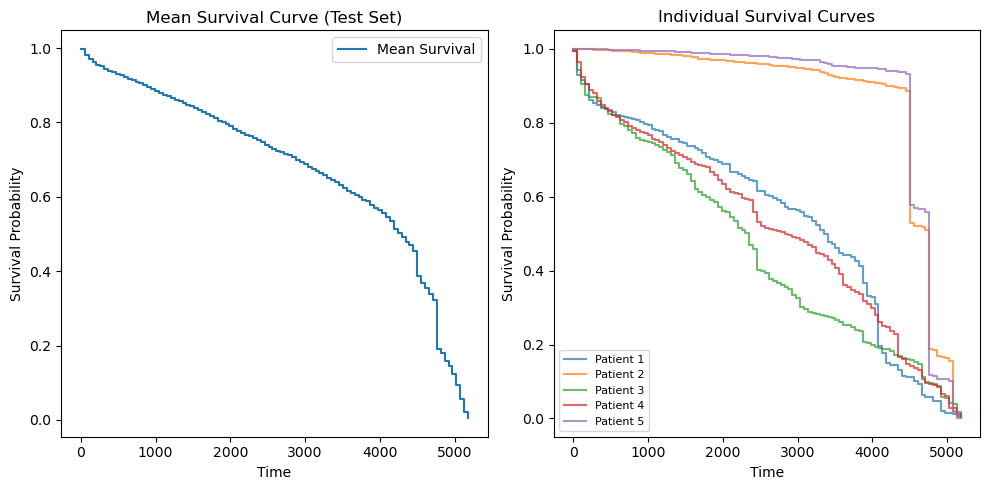

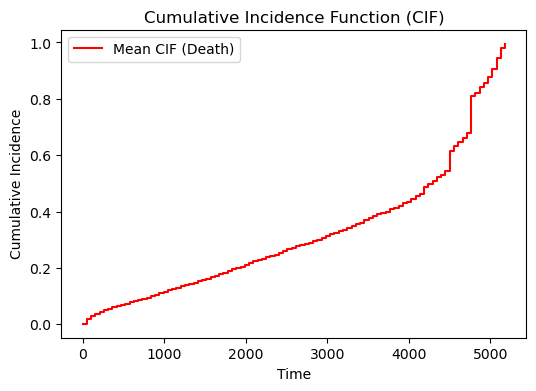


C-index: 0.5960


In [60]:
# ------------------------------
# 1. Load and prepare data
# ------------------------------

# Assume 'T' = duration column, 'E' = event indicator
T_train = df_stroke_train["Ictus_date"]         
T_test = df_stroke_test["Ictus_date"]         
T_eval = df_stroke_eval["Ictus_date"]         
E_train = df_stroke_train["events"]
E_test = df_stroke_test["events"]
E_eval = df_stroke_eval["events"]
X_train = df_stroke_train.drop(columns=["Ictus_date", "events"]) 
X_test = df_stroke_test.drop(columns=["Ictus_date", "events"]) 
X_eval = df_stroke_eval.drop(columns=["Ictus_date", "events"]) 

X_train_np = X_train.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
X_eval_np  = X_eval.values.astype('float32')

# ------------------------------
# 2. Define DeepHit network
# ------------------------------

# Choose number of discrete time intervals
num_durations = 100  # can also try 200

labtrans = LabTransDiscreteTime(num_durations)

# Fit and transform train labels
y_train = labtrans.fit_transform(T_train.values, E_train.values) 
y_test = labtrans.transform(T_test.values, E_test.values)
y_eval = labtrans.transform(T_eval.values, E_eval.values)

# Now the number of output nodes = labtrans.out_features
out_features = labtrans.out_features
print("Network output nodes needed:", out_features)

in_features = X_train.shape[1]
num_nodes = [64, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(
    in_features, 
    num_nodes, 
    out_features = out_features ,  # output nodes for discretized times
    batch_norm=True, 
    dropout=dropout, 
    activation=torch.nn.ReLU
)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# Define DeepHit model
model = DeepHitSingle(net, tt.optim.AdamWR, duration_index=labtrans.cuts)  # duration_index will be inferred automatically

# ------------------------------
# 3. Train model
# ------------------------------
epochs = 50
batch_size = 128

log = model.fit(
    X_train_np, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
    val_data=(X_eval_np, y_eval)
)

# ------------------------------
# 4. Predict survival functions
# ------------------------------
surv = model.predict_surv_df(X_test_np)  # returns survival probability over discretized times

# ------------------------------
# 5. Evaluate model
# ------------------------------
# For competing risks, we evaluate CIF for each event type
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')

# Concordance index (overall)
c_index = ev.concordance_td()
print("C-index:", c_index)

# ------------------------------
# 6. Plot survival curves
# ------------------------------
times = surv.index.values

# Option A: Plot mean survival curve across all test patients
mean_surv = surv.mean(axis=1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.step(times, mean_surv, where='post', label='Mean Survival')
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Mean Survival Curve (Test Set)")
plt.legend()

# Option B: Plot a few individual patient survival curves
plt.subplot(1, 2, 2)
for i in range(min(5, surv.shape[1])):  # plot first 5 patients
    plt.step(times, surv.iloc[:, i], where='post', alpha=0.7, label=f"Patient {i+1}")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Individual Survival Curves")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Plot CIF (1 - Survival)
# ------------------------------
plt.figure(figsize=(6, 4))
mean_cif = 1 - mean_surv
plt.step(times, mean_cif, where='post', color='red', label='Mean CIF (Death)')
plt.xlabel("Time")
plt.ylabel("Cumulative Incidence")
plt.title("Cumulative Incidence Function (CIF)")
plt.legend()
plt.show()

print(f"\nC-index: {c_index:.4f}")

# URRAH DATASET

In [61]:
df = pd.read_excel("Progetto/Dataset Sirbu/URRAH_TG_conLegenda.xlsx",sheet_name=None)

print(df.keys()) 
df_value = df["Urrah_virdis"]
df_legend = df["Legenda"]

print(df_value.info())

dict_keys(['Urrah_virdis', 'Legenda'])
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27078 entries, 0 to 27077
Data columns (total 85 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SESSO                           27078 non-null  int64  
 1   SESSO0                          27078 non-null  object 
 2   ETA                             27074 non-null  float64
 3   FAM_IPERT                       18938 non-null  float64
 4   FAM_CV                          16383 non-null  float64
 5   DIABETE                         25902 non-null  float64
 6   FUMO_ATT                        24526 non-null  float64
 7   EXFUMO                          22055 non-null  float64
 8   ALCOOL                          19514 non-null  float64
 9   ETANOLO_G_DIE                   7230 non-null   float64
 10  ATT_FIS                         13605 non-null  float64
 11  ATT_FIS_H_SETT                  6797 non-null   float6

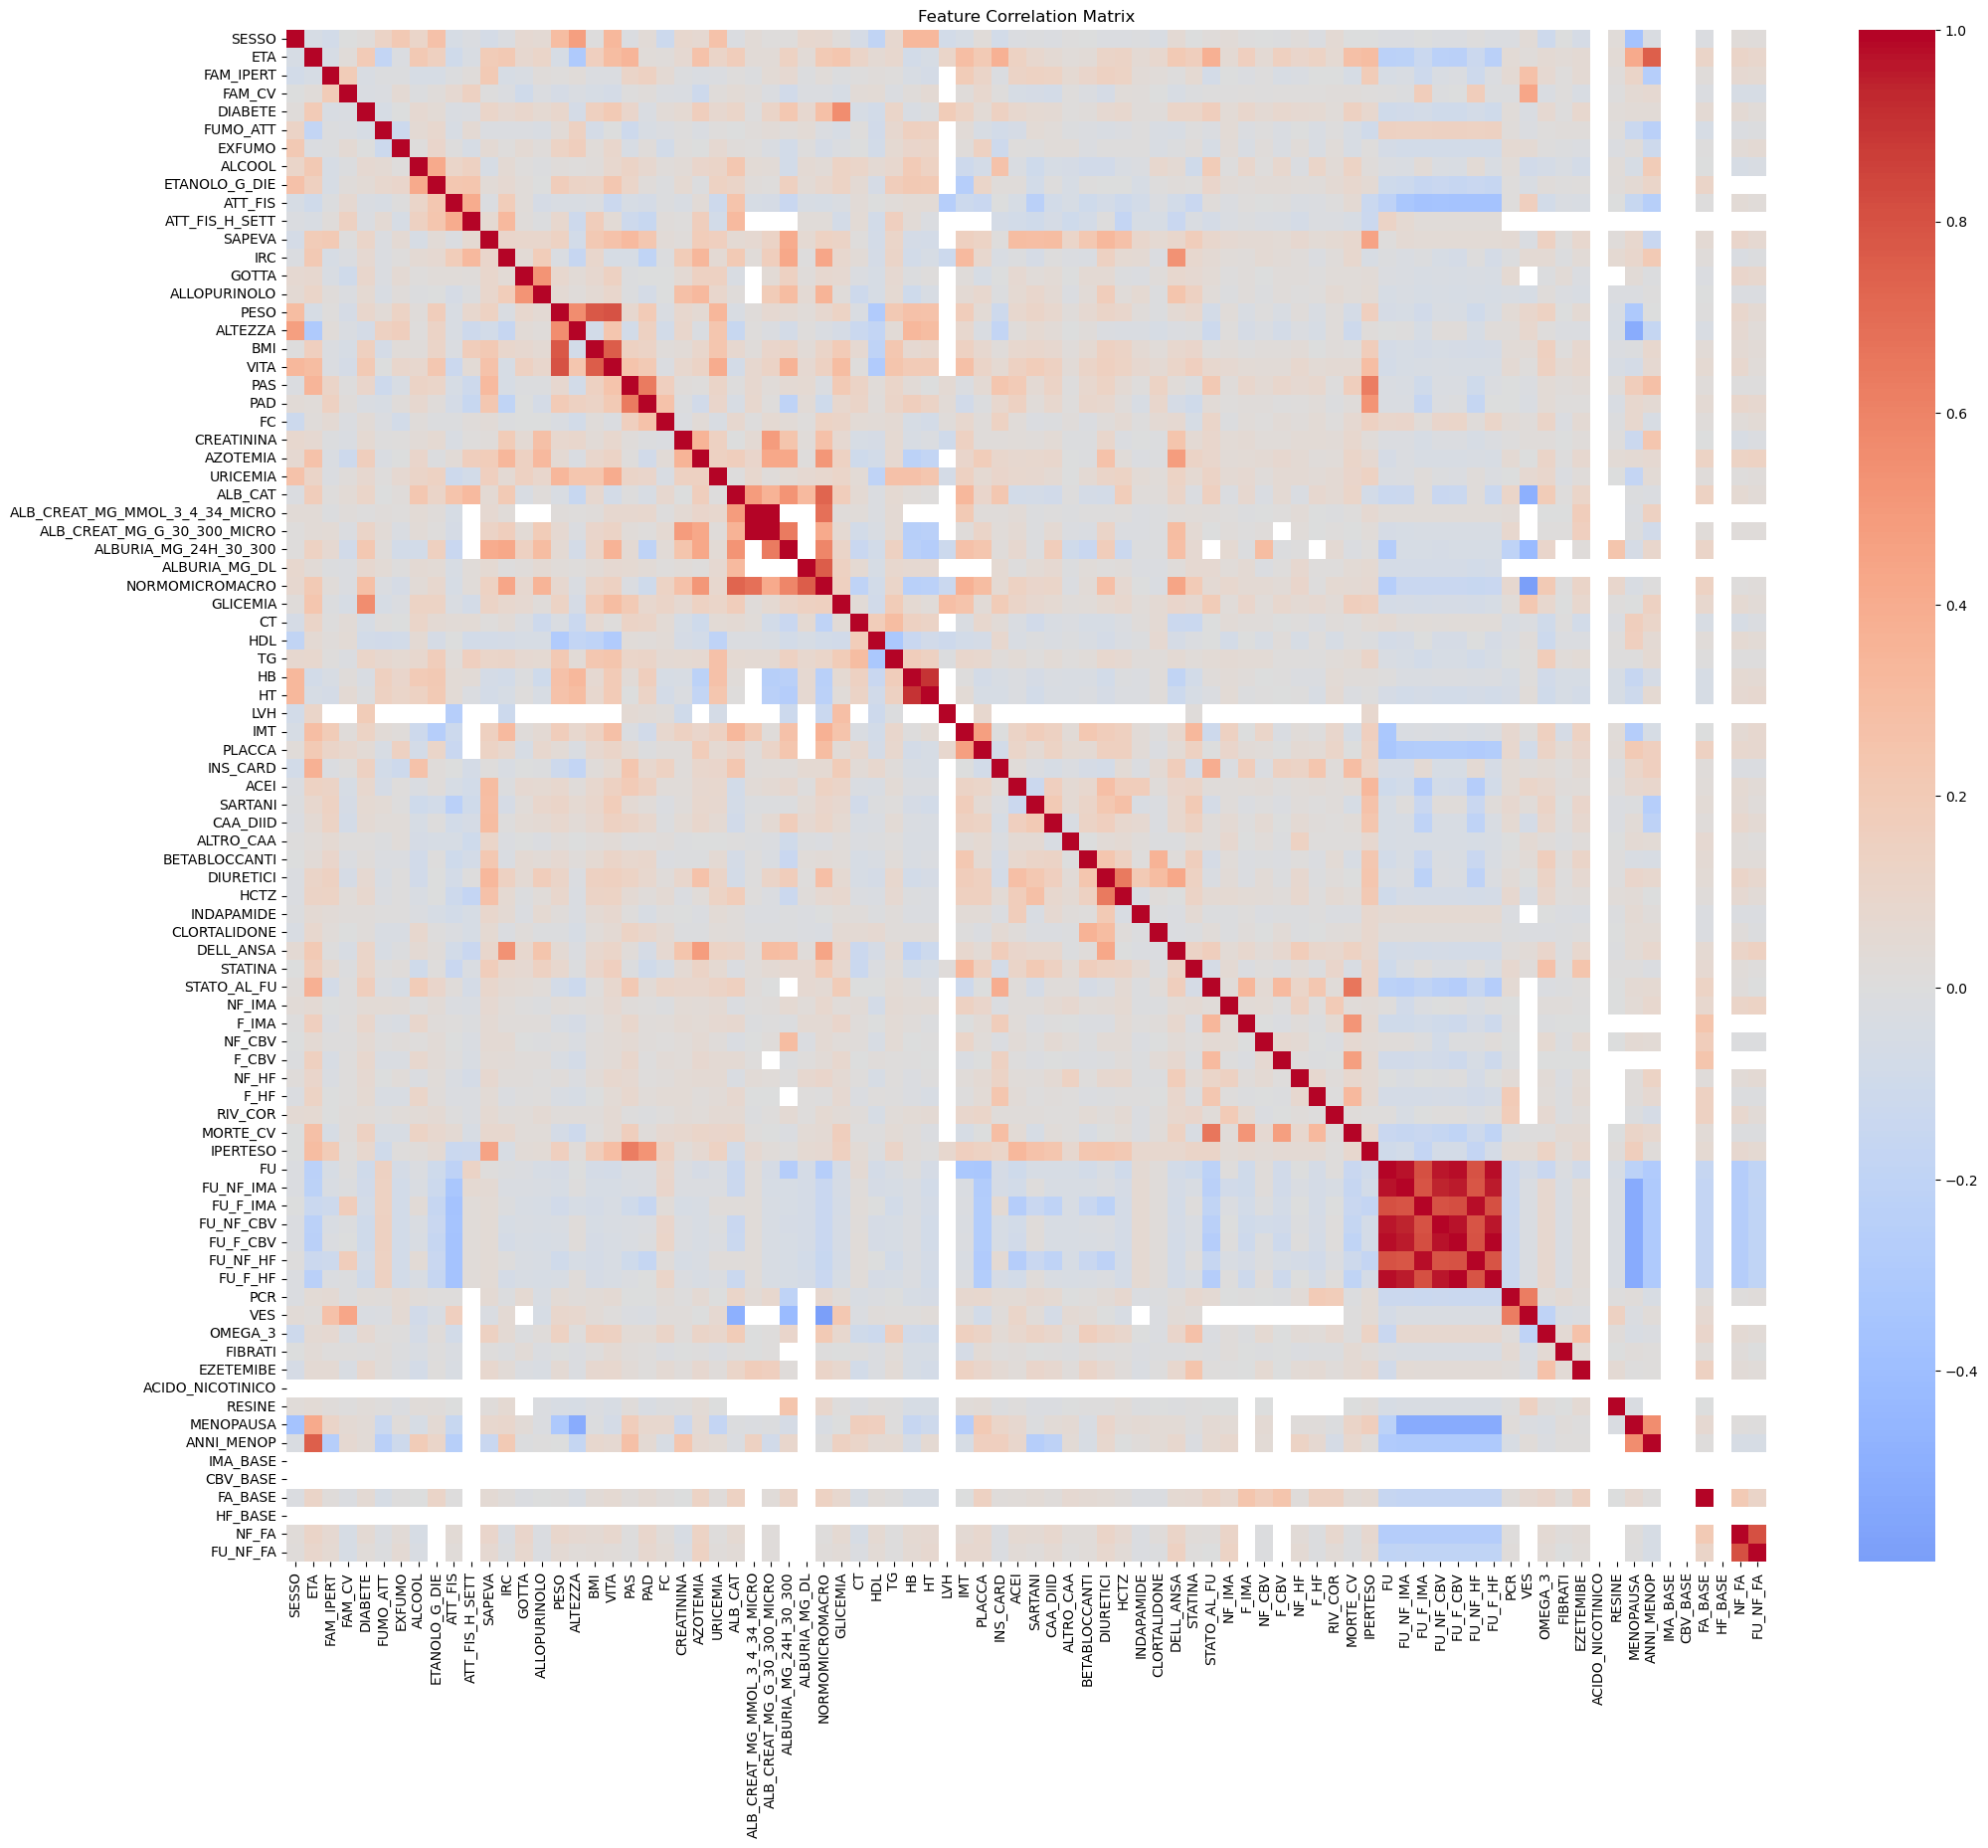

In [62]:
numeric_df = df_value.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [63]:
# Example preprocessing steps
df_value.loc[:, "FU"] = np.floor(df_value["FU"]).astype(float)
df_value = df_value.dropna(subset=["FU","STATO_AL_FU"])

cols_max = ["FU_F_IMA", "FU_F_CBV", "FU_F_HF","FU"]

df_value.loc[:, "FU"] = np.where(
    df_value["STATO_AL_FU"] == 1,
    df_value[cols_max].min(axis=1),
    df_value["FU"]
)
mask_sesso = df_value["SESSO"] == 1

df_value.loc[mask_sesso, ["MENOPAUSA", "ANNI_MENOP"]] = -1

mask = (df_value["SESSO"] == 0) & (df_value["MENOPAUSA"] == 0)

df_value.loc[mask, "ANNI_MENOP"] = 0

mask_meno = df_value["MENOPAUSA"] == 1

mask_meno = df_value["MENOPAUSA"] == 1
invalid_mask = mask_meno & (df_value["ANNI_MENOP"] <= 0)

mean_anni = df_value[
    (df_value["MENOPAUSA"] == 1) & 
    (df_value["SESSO"] == 0) & 
    (df_value["ANNI_MENOP"] > 0)
]["ANNI_MENOP"].mean()

df_value.loc[invalid_mask, "ANNI_MENOP"] = mean_anni

df_value['MENOPAUSA'] = df_value['MENOPAUSA'].fillna(
    (df_value['ETA'] > 50).astype(int)
)

df_value['ANNI_MENOP'] = df_value['ANNI_MENOP'].fillna(
    df_value.apply(
        lambda row: row['ETA'] - 50 if row['MENOPAUSA'] == 1 else 0, axis=1
    )
)

df_value.drop(columns=["LVH","VES","SAPEVA","SESSO0"], inplace=True)

has_any_measurement = (
    df_value['ALB_CREAT_MG_MMOL_3_4_34_MICRO'].notna() | 
    df_value['ALB_CREAT_MG_G_30_300_MICRO'].notna()
)

df_value['ALB_CAT'] = (
    (df_value['ALB_CREAT_MG_MMOL_3_4_34_MICRO'] > 3.4) | 
    (df_value['ALB_CREAT_MG_G_30_300_MICRO'] > 30)
).astype(float)

df_value.loc[~has_any_measurement, 'ALB_CAT'] = float('nan')

df_value = df_value.drop(columns=["ALB_CREAT_MG_MMOL_3_4_34_MICRO","ALB_CREAT_MG_G_30_300_MICRO","ALBURIA_MG_24H_30_300","ALBURIA_MG_DL"])

/var/folders/c2/t7280dm91png3l2ygs772wyw0000gn/T/ipykernel_56381/1699595657.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_value['MENOPAUSA'] = df_value['MENOPAUSA'].fillna(
/var/folders/c2/t7280dm91png3l2ygs772wyw0000gn/T/ipykernel_56381/1699595657.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_value['ANNI_MENOP'] = df_value['ANNI_MENOP'].fillna(
/var/folders/c2/t7280dm91png3l2ygs772wyw0000gn/T/ipykernel_56381/1699595657.py:43: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [64]:
cols = ['ACEI', 
        'SARTANI', 
        'CAA_DIID', 
        'ALTRO_CAA',
        'BETABLOCCANTI', 
        'DIURETICI', 
        'HCTZ', 
        'INDAPAMIDE',
        'CLORTALIDONE', 
        'DELL_ANSA', 
        'STATINA',
        "PLACCA",
        "INS_CARD",
        "GOTTA",
        "ALLOPURINOLO",
        "RIV_COR",
        "FAM_CV",
        "FAM_IPERT",
        "EXFUMO",
        "IRC",
        "FUMO_ATT"
]

df_value[cols] = df_value[cols].fillna(-1)

In [65]:
from sklearn.impute import KNNImputer
cols = ["AZOTEMIA","VITA","HB","HT","GLICEMIA","HDL","CREATININA","FC","CT"]

knn_imputer = KNNImputer(n_neighbors=5)
df_value[cols] = knn_imputer.fit_transform(df_value[cols])

In [66]:
df_value["ALCOOL"] = df_value["ALCOOL"].fillna(-1)

df_value.loc[df_value['ALCOOL'] == -1, 'ETANOLO_G_DIE'] = -1

df_value.loc[df_value['ALCOOL'] == 0, 'ETANOLO_G_DIE'] = 0

null_count = df_value[(df_value['ALCOOL'] == 1) & (df_value['ETANOLO_G_DIE'].isnull())].shape[0]
print(f"NaN in ETANOLO_G_DIE con ALCOOL=1: {null_count}")

NaN in ETANOLO_G_DIE con ALCOOL=1: 5161


In [67]:
mean_etanolo = df_value[df_value['ALCOOL'] == 1]['ETANOLO_G_DIE'].mean()
print(f"Media ETANOLO_G_DIE (ALCOOL=1): {mean_etanolo:.2f}")

df_value.loc[
    (df_value['ALCOOL'] == 1) & (df_value['ETANOLO_G_DIE'].isnull()), 
    'ETANOLO_G_DIE'
] = mean_etanolo

Media ETANOLO_G_DIE (ALCOOL=1): 32.68


In [68]:
df_value["ATT_FIS"] = df_value["ATT_FIS"].fillna(-1)

df_value.loc[df_value['ATT_FIS'] == -1, 'ATT_FIS_H_SETT'] = -1

df_value.loc[df_value['ATT_FIS'] == 0, 'ATT_FIS_H_SETT'] = 0

null_count = df_value[(df_value['ATT_FIS'] == 1) & (df_value['ATT_FIS_H_SETT'].isnull())].shape[0]
print(f"NaN in ATT_FIS_H_SETT con ATT_FIS=1: {null_count}")

NaN in ATT_FIS_H_SETT con ATT_FIS=1: 1505


In [69]:
mean_sport = df_value[df_value['ATT_FIS'] == 1]['ATT_FIS_H_SETT'].mean()
print(f"Media ATT_FIS_H_SETT (ATT_FIS=1): {mean_etanolo:.2f}")

df_value.loc[
    (df_value['ATT_FIS'] == 1) & (df_value['ATT_FIS_H_SETT'].isnull()), 
    'ATT_FIS_H_SETT'
] = mean_sport

Media ATT_FIS_H_SETT (ATT_FIS=1): 32.68


In [70]:
df_value = df_value.drop(columns=["IMT","CBV_BASE","IMA_BASE","HF_BASE","NF_FA","FU_NF_FA","FA_BASE","ALB_CAT","PCR","RESINE","ACIDO_NICOTINICO","OMEGA_3","FIBRATI","EZETEMIBE","NORMOMICROMACRO"])

In [71]:
df_value = df_value.dropna()

In [72]:
df_value['time'] = pd.qcut(df_value['FU'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_value['stratum'] = df_value['STATO_AL_FU'].astype(str) + '_' + df_value['time'].astype(str)

df_mortality_train, df_tmp = train_test_split(
    df_value, test_size=0.2, random_state=42,
    stratify=df_value["stratum"]
)

df_mortality_eval, df_mortality_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_mortality_train, df_mortality_eval, df_mortality_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)
df_value.drop(columns=['time','stratum'],inplace=True)

binary_cols = [
    col for col in df_mortality_train.columns
    if set(df_value[col].dropna().unique()).issubset({0,1})
]

cols_to_keep = binary_cols + ["FU"]
    
tmp_train = df_mortality_train[cols_to_keep].copy()
tmp_test = df_mortality_test[cols_to_keep].copy()
tmp_eval = df_mortality_eval[cols_to_keep].copy()
    
df_mortality_train = df_mortality_train.drop(columns=cols_to_keep)
df_mortality_test = df_mortality_test.drop(columns=cols_to_keep)
df_mortality_eval = df_mortality_eval.drop(columns=cols_to_keep)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_mortality_train)
scaled_array_test = scaler.transform(df_mortality_test)
scaled_array_eval = scaler.transform(df_mortality_eval)
    
df_mortality_train = pd.DataFrame(scaled_array_train, columns=df_mortality_train.columns, index=df_mortality_train.index)
df_mortality_test = pd.DataFrame(scaled_array_test, columns=df_mortality_test.columns, index=df_mortality_test.index)
df_mortality_eval = pd.DataFrame(scaled_array_eval, columns=df_mortality_eval.columns, index=df_mortality_eval.index)

df_mortality_train = pd.concat([df_mortality_train, tmp_train], axis=1)
df_mortality_test = pd.concat([df_mortality_test, tmp_test], axis=1)
df_mortality_eval = pd.concat([df_mortality_eval, tmp_eval], axis=1)

columns_to_drop = [
        "NF_IMA",
        "F_IMA",
        "NF_CBV",
        "F_CBV",
        "NF_HF",
        "F_HF",
        "RIV_COR",
        "MORTE_CV",
        "FU_NF_IMA",
        "FU_F_IMA",
        "FU_NF_CBV",
        "FU_F_CBV",
        "FU_NF_HF",
        "FU_F_HF"]

df_mortality_train = df_mortality_train.drop(columns=columns_to_drop)
df_mortality_test = df_mortality_test.drop(columns=columns_to_drop)
df_mortality_eval = df_mortality_eval.drop(columns=columns_to_drop)

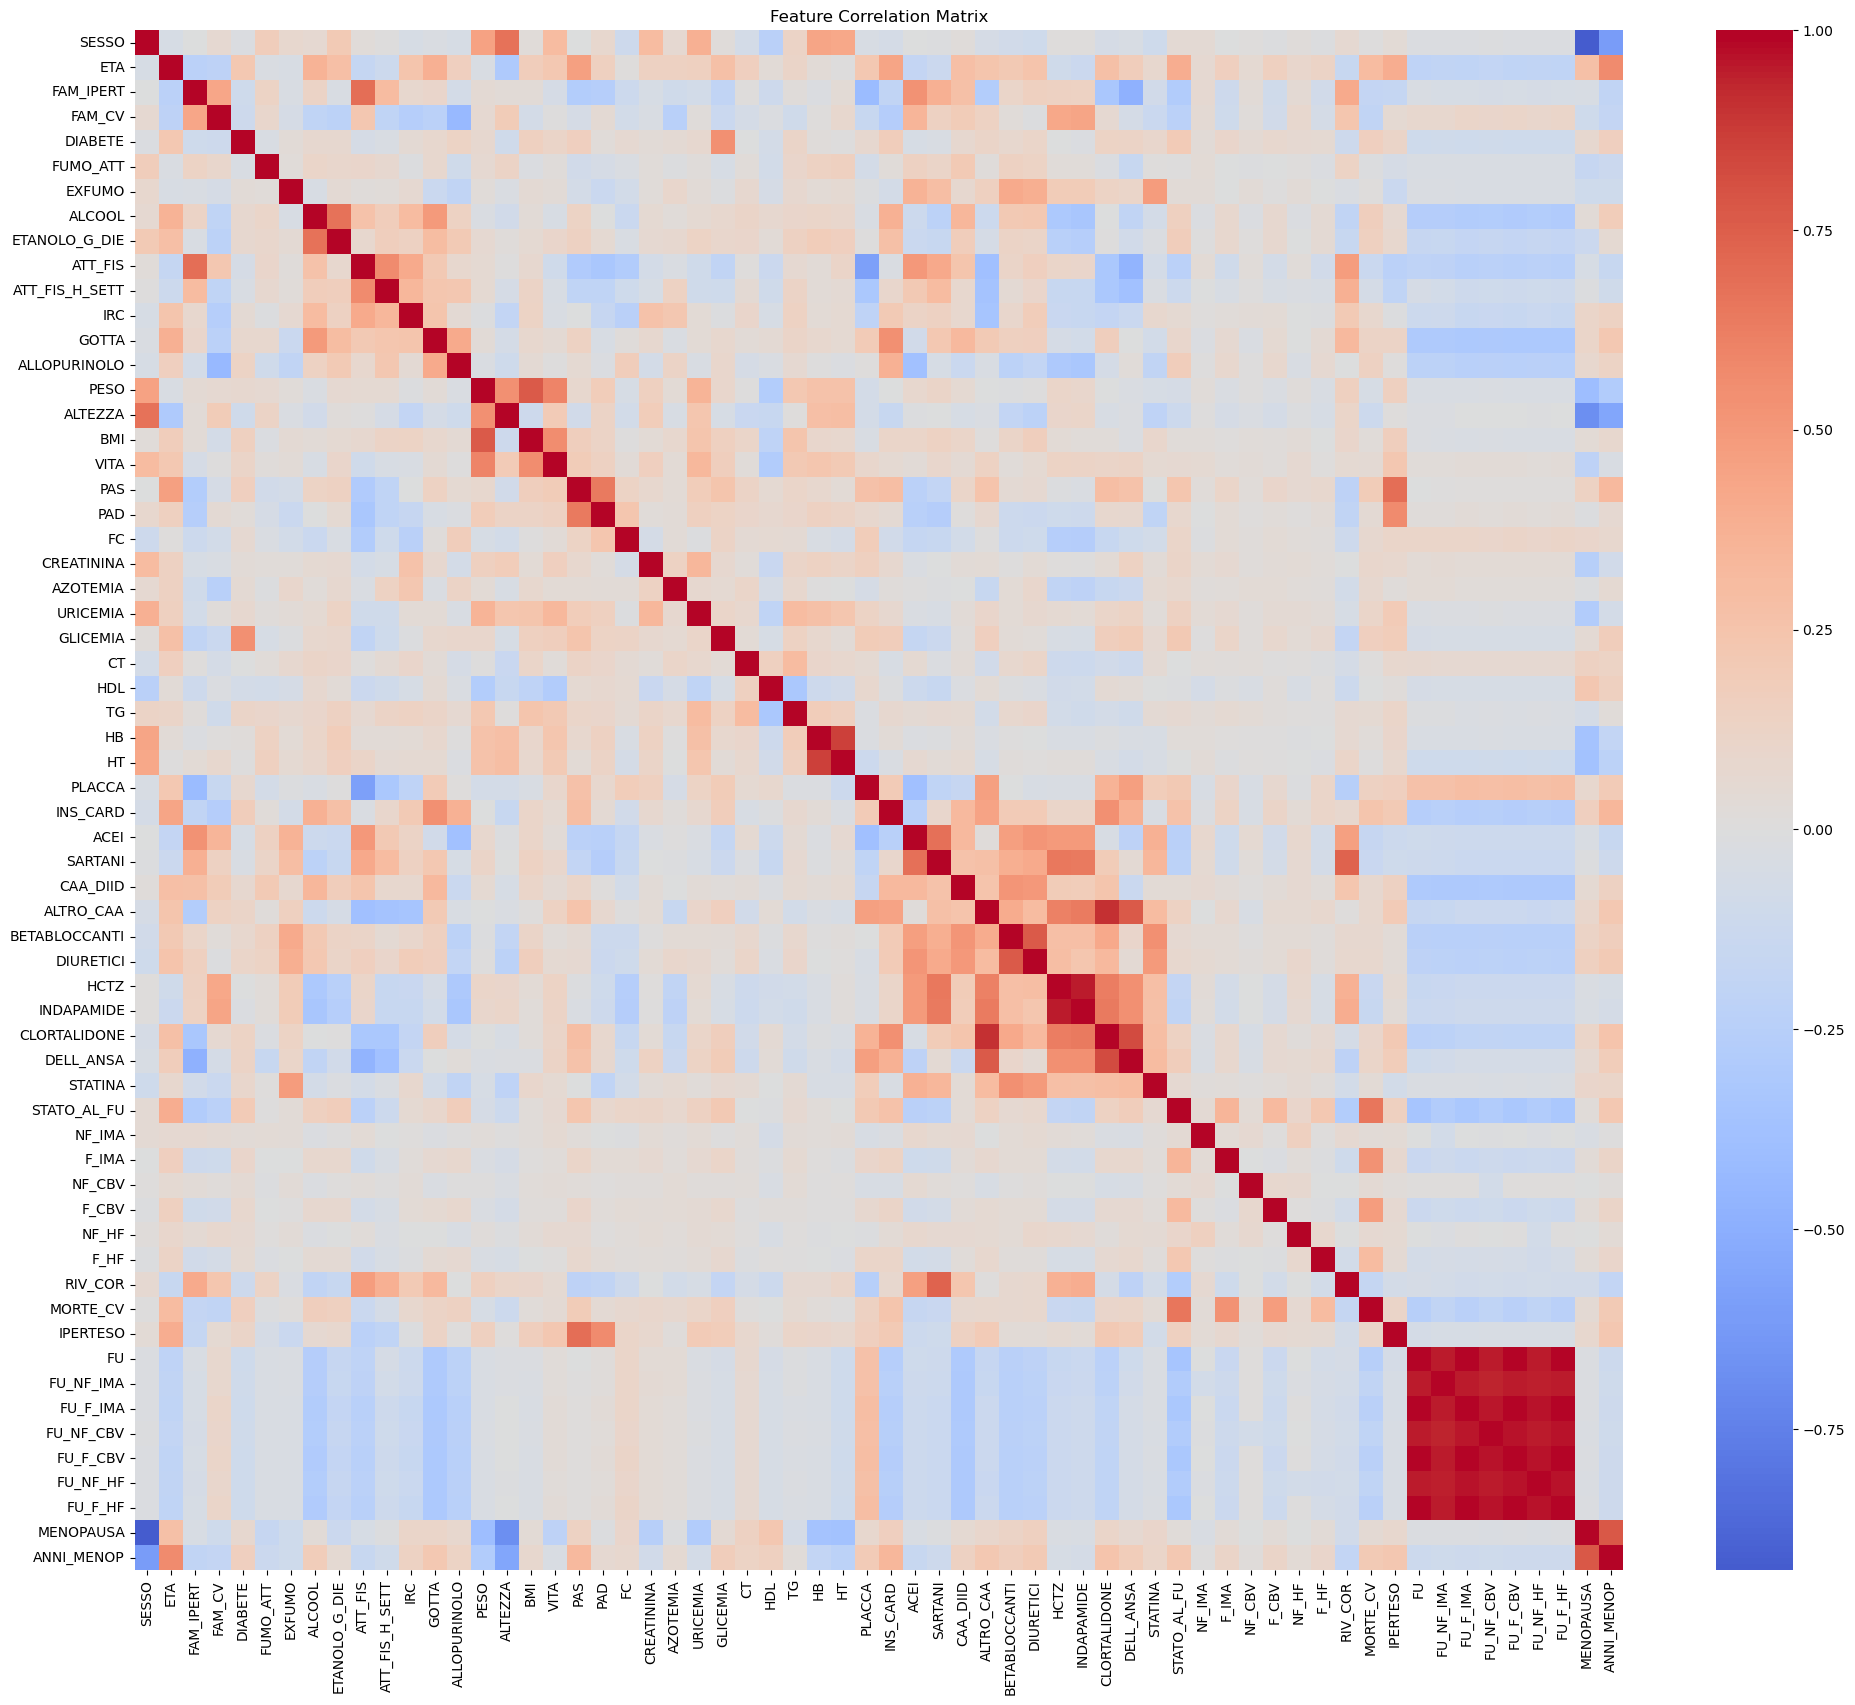

In [73]:
numeric_df = df_value.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [74]:
corr_threshold = 0.90

corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [column for column in upper.columns if any(upper[column] > corr_threshold)]

print("Highly correlated features:")
print(high_corr_features)

Highly correlated features:
['INDAPAMIDE', 'CLORTALIDONE', 'FU_NF_IMA', 'FU_F_IMA', 'FU_NF_CBV', 'FU_F_CBV', 'FU_NF_HF', 'FU_F_HF', 'MENOPAUSA']


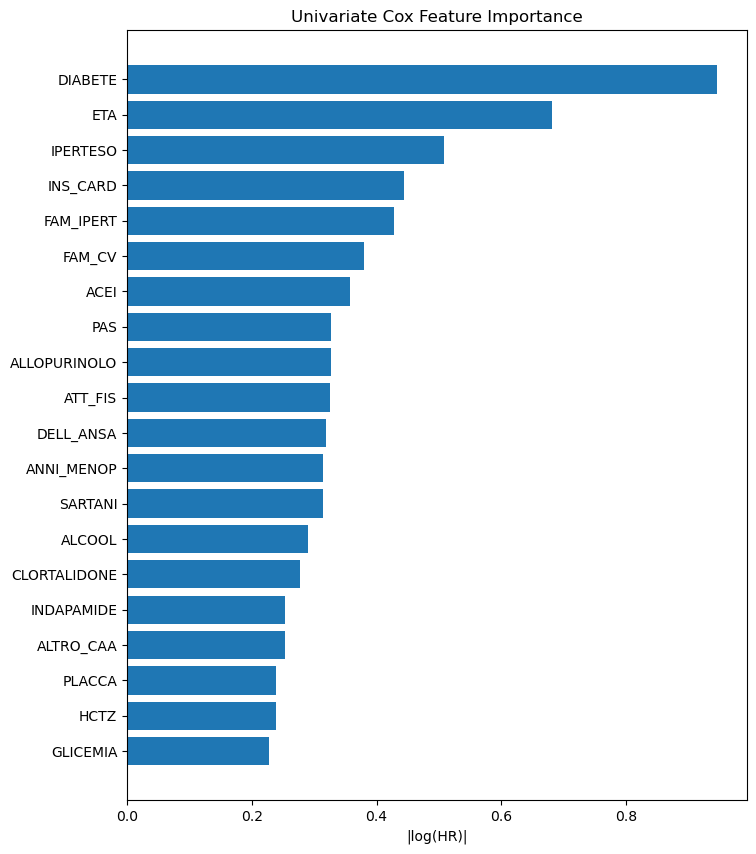

In [75]:
results = []
for c in df_mortality_train.columns: 
    if c not in ["FU", "STATO_AL_FU"]:
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(
            df_mortality_train[[c,'FU','STATO_AL_FU']], 
            duration_col='FU', 
            event_col='STATO_AL_FU')
        coef = cph.summary.loc[c, "coef"]
        se = cph.summary.loc[c, "se(coef)"]
        p = cph.summary.loc[c, "p"]
        results.append({"feature": c, "coef": coef, "se": se, "p": p})

importance = pd.DataFrame(results)
importance_temp = importance[importance["p"] < 0.05].copy()

importance["abs_logHR"] = importance["coef"].abs()
importance = importance[importance["p"] < 0.05]
importance = importance.sort_values("abs_logHR", ascending=False).head(20)

plt.figure(figsize=(8,10))
plt.barh(importance["feature"], importance["abs_logHR"])
plt.gca().invert_yaxis()
plt.xlabel("|log(HR)|")
plt.title("Univariate Cox Feature Importance")
plt.show()

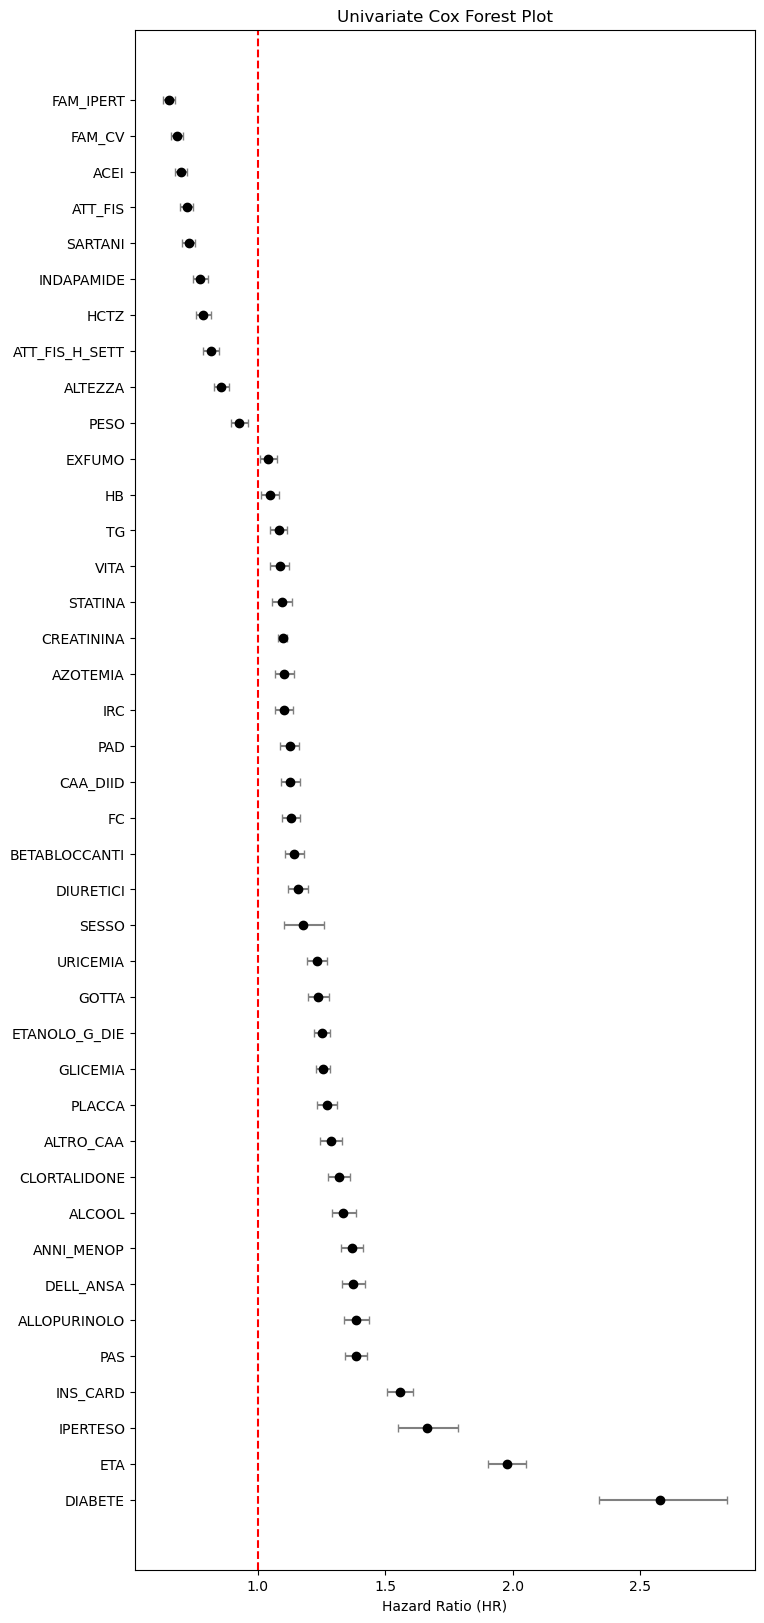

In [76]:
# Calculate HR and 95% CI
importance_temp["HR"] = np.exp(importance_temp["coef"])
importance_temp["HR_lower"] = np.exp(importance_temp["coef"] - 1.96*importance_temp["se"])
importance_temp["HR_upper"] = np.exp(importance_temp["coef"] + 1.96*importance_temp["se"])

# Sort by HR
importance_temp = importance_temp.sort_values("HR")

# Plot forest plot
plt.figure(figsize=(8, len(importance_temp)*0.5))
plt.errorbar(
    importance_temp["HR"],
    range(len(importance_temp)),
    xerr=[importance_temp["HR"] - importance_temp["HR_lower"], importance_temp["HR_upper"] - importance_temp["HR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)
plt.yticks(range(len(importance_temp)), importance_temp["feature"])
plt.axvline(x=1, color='red', linestyle='--')  # no-effect line
plt.xlabel("Hazard Ratio (HR)")
plt.title("Univariate Cox Forest Plot")
plt.gca().invert_yaxis()
plt.show()

Concordance Index: 0.8420342950439681


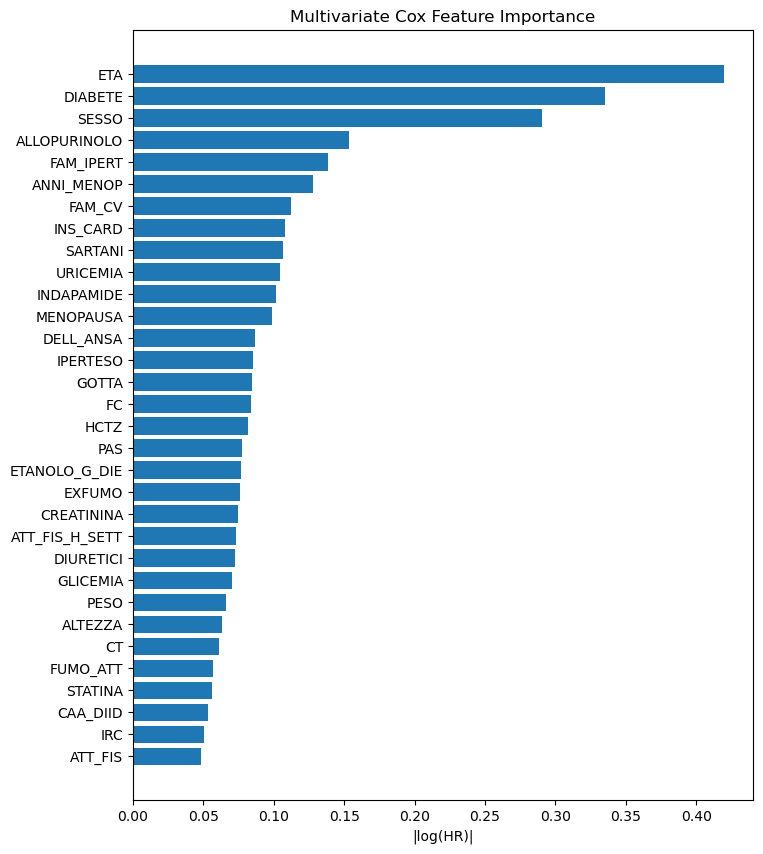

In [77]:
# Columns to use as covariates (exclude duration/event)
#covariates = [c for c in df_mortality.columns if c not in ['Data of death', 'Total mortality']]

# Fit multivariate Cox model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_mortality_train,#[covariates],# + ['Data of death', 'Total mortality']], 
        duration_col='FU', 
        event_col='STATO_AL_FU')

print("Concordance Index:", cph.concordance_index_)

# Extract results
importance = cph.summary.reset_index()
importance.rename(columns={'index':'feature'}, inplace=True)

# Keep only significant features
importance = importance[importance["p"] < 0.05].copy()
importance_temp = importance.copy()

# Calculate |log(HR)|
importance["abs_logHR"] = importance["coef"].abs()

# Sort by |log(HR)| for plotting
importance = importance.sort_values("abs_logHR", ascending=False)  # top 20 if needed: .head(20)

# Plot |log(HR)|
plt.figure(figsize=(8,10))
plt.barh(importance["covariate"], importance["abs_logHR"])
plt.gca().invert_yaxis()
plt.xlabel("|log(HR)|")
plt.title("Multivariate Cox Feature Importance")
plt.show()

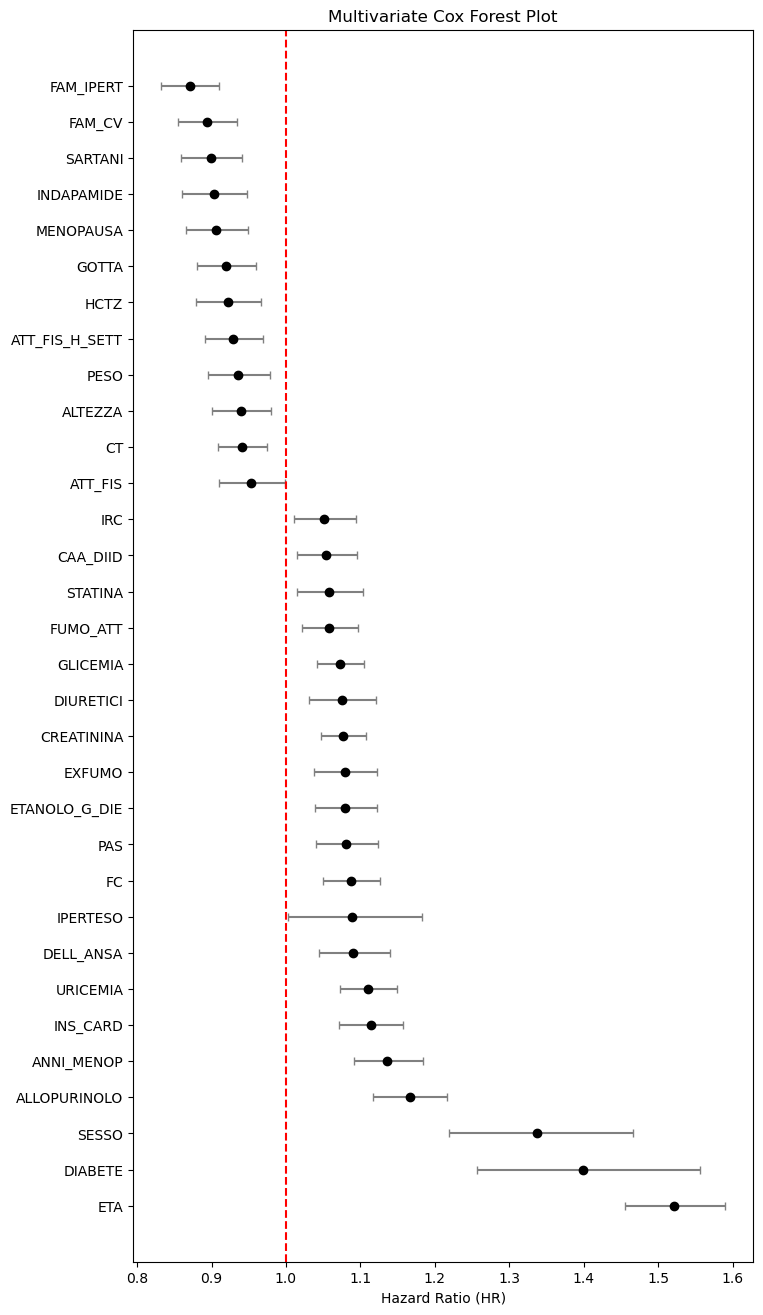

In [78]:
# Calculate HR and 95% CI
importance_temp["HR"] = np.exp(importance_temp["coef"])
importance_temp["HR_lower"] = np.exp(importance_temp["coef"] - 1.96*importance_temp["se(coef)"])
importance_temp["HR_upper"] = np.exp(importance_temp["coef"] + 1.96*importance_temp["se(coef)"])

# Sort by HR for plotting
importance_temp = importance_temp.sort_values("HR")

# Plot forest plot
plt.figure(figsize=(8, len(importance_temp)*0.5))
plt.errorbar(
    importance_temp["HR"],
    range(len(importance_temp)),
    xerr=[importance_temp["HR"] - importance_temp["HR_lower"], importance_temp["HR_upper"] - importance_temp["HR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)
plt.yticks(range(len(importance_temp)), importance_temp["covariate"])
plt.axvline(x=1, color='red', linestyle='--') 
plt.xlabel("Hazard Ratio (HR)")
plt.title("Multivariate Cox Forest Plot")
plt.gca().invert_yaxis()
plt.show()

In [79]:
# Assume 'T' = duration column, 'E' = event indicator
T_train = df_mortality_train["FU"]         
E_train = df_mortality_train["STATO_AL_FU"]
X_train = df_mortality_train.drop(columns=["FU", "STATO_AL_FU"])
T_test = df_mortality_test["FU"]
E_test = df_mortality_test["STATO_AL_FU"]
X_test = df_mortality_test.drop(columns=["FU", "STATO_AL_FU"])
T_eval = df_mortality_eval["FU"]
E_eval = df_mortality_eval["STATO_AL_FU"]
X_eval = df_mortality_eval.drop(columns=["FU", "STATO_AL_FU"])

# Convert DataFrames / Series to torch tensors for pycox
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
X_eval_tensor = torch.tensor(X_eval.values, dtype=torch.float32)
T_train_tensor = torch.tensor(T_train.values, dtype=torch.float32)
T_test_tensor = torch.tensor(T_test.values, dtype=torch.float32)
T_eval_tensor = torch.tensor(T_eval.values, dtype=torch.float32)
E_train_tensor = torch.tensor(E_train.values, dtype=torch.float32)
E_test_tensor = torch.tensor(E_test.values, dtype=torch.float32)
E_eval_tensor = torch.tensor(E_eval.values, dtype=torch.float32)


In [80]:
# Network definition
in_features = X_train.shape[1]
num_nodes = [32, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(in_features, num_nodes, 1, batch_norm=True, dropout=dropout, activation=nn.ReLU)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# DeepSurv model
model = CoxPH(net, tt.optim.AdamWR)

In [81]:
# Prepare dataset for pycox

# DeepSurv uses Cox PH loss, no need to transform labels
# But pycox allows easy handling of mini-batches

# Fit model
epochs = 100
batch_size = 128

model.fit(X_train_tensor, 
          (T_train_tensor, E_train_tensor), 
          batch_size, 
          epochs, 
          verbose=True,
          val_data=(X_eval_tensor, (T_eval_tensor, E_eval_tensor)))

0:	[0s / 0s],		train_loss: 4.0151,	val_loss: 6.5454
1:	[0s / 0s],		train_loss: 3.8489,	val_loss: 6.4002
2:	[0s / 0s],		train_loss: 3.7558,	val_loss: 6.3706
3:	[0s / 0s],		train_loss: 3.7088,	val_loss: 6.2996
4:	[0s / 1s],		train_loss: 3.6412,	val_loss: 6.2567
5:	[0s / 1s],		train_loss: 3.5989,	val_loss: 6.2442
6:	[0s / 1s],		train_loss: 3.5923,	val_loss: 6.2436
7:	[0s / 1s],		train_loss: 3.5934,	val_loss: 6.2182
8:	[0s / 2s],		train_loss: 3.5627,	val_loss: 6.2161
9:	[0s / 2s],		train_loss: 3.5461,	val_loss: 6.2041
10:	[0s / 2s],		train_loss: 3.5396,	val_loss: 6.2101
11:	[0s / 2s],		train_loss: 3.4948,	val_loss: 6.2175
12:	[0s / 3s],		train_loss: 3.5166,	val_loss: 6.2145
13:	[0s / 3s],		train_loss: 3.4994,	val_loss: 6.2116
14:	[0s / 3s],		train_loss: 3.4991,	val_loss: 6.2114
15:	[0s / 3s],		train_loss: 3.5255,	val_loss: 6.2184
16:	[0s / 3s],		train_loss: 3.4936,	val_loss: 6.2127
17:	[0s / 4s],		train_loss: 3.4972,	val_loss: 6.2162
18:	[0s / 4s],		train_loss: 3.4876,	val_loss: 6.2354
19:

In [82]:
# Concordance index
from pycox.evaluation import EvalSurv

# Predict log-risk for test set
risk_scores = model.predict(X_test_tensor)

# Convert to survival function
# For Cox, higher risk score = higher hazard
# EvalSurv can compute C-index

# Use Kaplan-Meier baseline estimate
baseline_hazard = model.compute_baseline_hazards()
surv = model.predict_surv_df(X_test_tensor)

# Concordance index
from pycox.evaluation import EvalSurv
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')
c_index = ev.concordance_td()
print("C-index:", c_index)

C-index: 0.8378263695785634


## Cardiovascular Mortality

In [83]:
df_cardiovascular = df_value.copy()
df_cardiovascular["Other deaths"] = df_cardiovascular["STATO_AL_FU"] - df_cardiovascular["MORTE_CV"]
df_cardiovascular["death"] = 0
df_cardiovascular.loc[df_cardiovascular["MORTE_CV"] == 1, "death"] = 1
df_cardiovascular.loc[df_cardiovascular["Other deaths"] == 1, "death"] = 2
df_cardiovascular["death"].value_counts()

death
0    13489
2     1428
1     1301
Name: count, dtype: int64

In [84]:
df_cardiovascular.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16218 entries, 2624 to 27077
Data columns (total 64 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SESSO           16218 non-null  int64  
 1   ETA             16218 non-null  float64
 2   FAM_IPERT       16218 non-null  float64
 3   FAM_CV          16218 non-null  float64
 4   DIABETE         16218 non-null  float64
 5   FUMO_ATT        16218 non-null  float64
 6   EXFUMO          16218 non-null  float64
 7   ALCOOL          16218 non-null  float64
 8   ETANOLO_G_DIE   16218 non-null  float64
 9   ATT_FIS         16218 non-null  float64
 10  ATT_FIS_H_SETT  16218 non-null  float64
 11  IRC             16218 non-null  float64
 12  GOTTA           16218 non-null  float64
 13  ALLOPURINOLO    16218 non-null  float64
 14  PESO            16218 non-null  float64
 15  ALTEZZA         16218 non-null  float64
 16  BMI             16218 non-null  float64
 17  VITA            16218 non-null  f

In [85]:
df_cardiovascular["FU"] = np.where(
    df_cardiovascular["MORTE_CV"] == 1,
    df_cardiovascular[["FU_F_IMA", "FU_F_CBV", "FU_F_HF"]].min(axis=1),
    df_cardiovascular["FU"]
)

In [86]:
# Split dataset into train, eval, and test sets

df_cardiovascular['time'] = pd.qcut(df_cardiovascular['FU'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_cardiovascular['stratum'] = df_cardiovascular['death'].astype(str) + '_' + df_cardiovascular['time'].astype(str)

df_cardiovascular_train, df_tmp = train_test_split(
    df_cardiovascular, test_size=0.2, random_state=42,
    stratify=df_cardiovascular["stratum"]
)

df_cardiovascular_eval, df_cardiovascular_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_cardiovascular_train, df_cardiovascular_eval, df_cardiovascular_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)

print(f"Train set: {len(df_cardiovascular_train)} samples")
print(f"Eval set: {len(df_cardiovascular_eval)} samples")
print(f"Test set: {len(df_cardiovascular_test)} samples")

Train set: 12974 samples
Eval set: 1622 samples
Test set: 1622 samples


In [87]:
for cause in [0, 1, 2]:
    print(f"\nEvent {cause}:")
    for name, split in [('Train', df_cardiovascular_train), ('Val', df_cardiovascular_eval), ('Test', df_cardiovascular_test)]:
        pct = (split['death'] == cause).mean()
        med = split.loc[split['death'] == cause, 'FU'].median()
        print(f"  {name}: {pct:.2%} of samples, median days={med:.0f}")


Event 0:
  Train: 83.17% of samples, median days=149
  Val: 83.23% of samples, median days=149
  Test: 83.11% of samples, median days=149

Event 1:
  Train: 8.02% of samples, median days=79
  Val: 7.95% of samples, median days=78
  Test: 8.08% of samples, median days=81

Event 2:
  Train: 8.80% of samples, median days=87
  Val: 8.82% of samples, median days=91
  Test: 8.82% of samples, median days=87


In [88]:
binary_cols = [
    col for col in df_cardiovascular_train.columns
    if set(df_cardiovascular_train[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['SESSO', 'DIABETE', 'STATO_AL_FU', 'NF_IMA', 'F_IMA', 'NF_CBV', 'F_CBV', 'NF_HF', 'MORTE_CV', 'IPERTESO']


In [89]:
df_cardiovascular_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12974 entries, 20545 to 17062
Data columns (total 64 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SESSO           12974 non-null  int64  
 1   ETA             12974 non-null  float64
 2   FAM_IPERT       12974 non-null  float64
 3   FAM_CV          12974 non-null  float64
 4   DIABETE         12974 non-null  float64
 5   FUMO_ATT        12974 non-null  float64
 6   EXFUMO          12974 non-null  float64
 7   ALCOOL          12974 non-null  float64
 8   ETANOLO_G_DIE   12974 non-null  float64
 9   ATT_FIS         12974 non-null  float64
 10  ATT_FIS_H_SETT  12974 non-null  float64
 11  IRC             12974 non-null  float64
 12  GOTTA           12974 non-null  float64
 13  ALLOPURINOLO    12974 non-null  float64
 14  PESO            12974 non-null  float64
 15  ALTEZZA         12974 non-null  float64
 16  BMI             12974 non-null  float64
 17  VITA            12974 non-null  

In [90]:
cols_to_keep = binary_cols + ["FU","death"]

tmp_train = df_cardiovascular_train[cols_to_keep].copy()
tmp_eval = df_cardiovascular_eval[cols_to_keep].copy()
tmp_test = df_cardiovascular_test[cols_to_keep].copy()

df_cardiovascular_train = df_cardiovascular_train.drop(columns=cols_to_keep)
df_cardiovascular_eval = df_cardiovascular_eval.drop(columns=cols_to_keep)
df_cardiovascular_test = df_cardiovascular_test.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_cardiovascular_train)
scaled_array_eval = scaler.transform(df_cardiovascular_eval)
scaled_array_test = scaler.transform(df_cardiovascular_test)

df_cardiovascular_train = pd.DataFrame(scaled_array_train, columns=df_cardiovascular_train.columns, index=df_cardiovascular_train.index)
df_cardiovascular_eval = pd.DataFrame(scaled_array_eval, columns=df_cardiovascular_eval.columns, index=df_cardiovascular_eval.index)
df_cardiovascular_test = pd.DataFrame(scaled_array_test, columns=df_cardiovascular_test.columns, index=df_cardiovascular_test.index)

df_cardiovascular_train = pd.concat([df_cardiovascular_train, tmp_train], axis=1)
df_cardiovascular_eval = pd.concat([df_cardiovascular_eval, tmp_eval], axis=1)
df_cardiovascular_test = pd.concat([df_cardiovascular_test, tmp_test], axis=1)

cols_to_drop = [ "FU_NF_IMA",
                 "FU_F_IMA",
                 "FU_NF_CBV",
                 "FU_F_CBV",
                 "FU_NF_HF",
                 "FU_F_HF",
                 "NF_IMA",
                 "F_IMA",
                 "NF_CBV",
                 "F_CBV",
                 "NF_HF",
                 "F_HF",
                 "MORTE_CV",
                 "Other deaths",
                 "STATO_AL_FU"
                ]

df_cardiovascular_train = df_cardiovascular_train.drop(columns=cols_to_drop)
df_cardiovascular_eval = df_cardiovascular_eval.drop(columns=cols_to_drop)
df_cardiovascular_test = df_cardiovascular_test.drop(columns=cols_to_drop)

print(df_cardiovascular_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12974 entries, 20545 to 17062
Data columns (total 49 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ETA             12974 non-null  float64
 1   FAM_IPERT       12974 non-null  float64
 2   FAM_CV          12974 non-null  float64
 3   FUMO_ATT        12974 non-null  float64
 4   EXFUMO          12974 non-null  float64
 5   ALCOOL          12974 non-null  float64
 6   ETANOLO_G_DIE   12974 non-null  float64
 7   ATT_FIS         12974 non-null  float64
 8   ATT_FIS_H_SETT  12974 non-null  float64
 9   IRC             12974 non-null  float64
 10  GOTTA           12974 non-null  float64
 11  ALLOPURINOLO    12974 non-null  float64
 12  PESO            12974 non-null  float64
 13  ALTEZZA         12974 non-null  float64
 14  BMI             12974 non-null  float64
 15  VITA            12974 non-null  float64
 16  PAS             12974 non-null  float64
 17  PAD             12974 non-null  

In [91]:
causes = [1, 2]
models = {}

for cause in causes:
    df_temp = df_cardiovascular_train.copy()
    df_temp["death"] = (df_temp["death"] == cause).astype(int)

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        df_temp,
        duration_col="FU",
        event_col='death'
    )
    models[cause] = cph

In [92]:
for model in models.values():
    print("Concordance Index:", model.concordance_index_)

Concordance Index: 0.8580731370660233
Concordance Index: 0.8180338260604619


                CV death  Other death    CV death p  Other death p
covariate                                                         
ETA             1.333105     1.333072  1.989578e-31   2.160576e-33
FAM_IPERT       0.921940     0.891905  9.405742e-04   2.002847e-06
FAM_CV          0.898682     0.921506  1.417382e-05   6.448543e-04
FUMO_ATT        1.021635     1.046585  3.394369e-01   2.635674e-02
EXFUMO          1.036797     1.068798  1.174341e-01   2.968099e-03
ALCOOL          1.069530     0.984620  5.764650e-03   5.128121e-01
ETANOLO_G_DIE   1.078122     1.053313  6.902452e-04   2.328063e-02
ATT_FIS         0.990014     0.940155  6.893536e-01   1.294053e-02
ATT_FIS_H_SETT  0.952551     0.977334  3.628816e-02   3.426229e-01
IRC             1.092543     1.020105  8.668114e-05   3.769902e-01
GOTTA           1.038446     0.935173  1.195893e-01   4.505105e-03
ALLOPURINOLO    1.137668     1.108566  7.315352e-08   1.027299e-05
PESO            0.948271     0.965999  2.598927e-02   1.430142

<Axes: xlabel='covariate'>

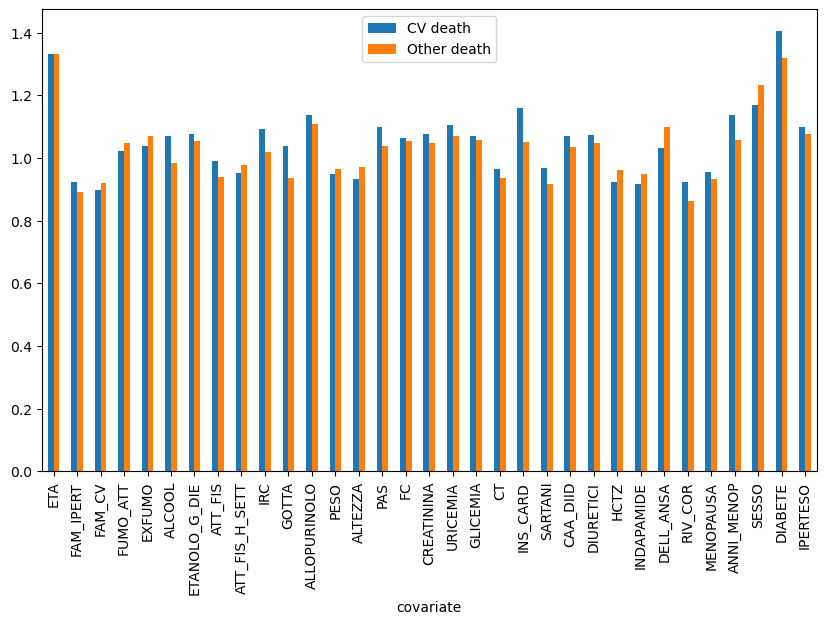

In [93]:
coef_cv = models[1].summary["exp(coef)"]
coef_other = models[2].summary["exp(coef)"]
p_cv = models[1].summary["p"]
p_other = models[2].summary["p"]

significant = (
    (p_cv < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "CV death": coef_cv,
    "Other death": coef_other,
    "CV death p": p_cv,
    "Other death p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["CV death","Other death"]].plot.bar(figsize=(10,6))

Network output nodes needed: 100
0:	[0s / 0s],		train_loss: 0.3576,	val_loss: 0.3480
1:	[0s / 1s],		train_loss: 0.3171,	val_loss: 0.3046
2:	[0s / 1s],		train_loss: 0.2944,	val_loss: 0.2986
3:	[0s / 2s],		train_loss: 0.2835,	val_loss: 0.2815
4:	[0s / 2s],		train_loss: 0.2689,	val_loss: 0.2745
5:	[0s / 3s],		train_loss: 0.2653,	val_loss: 0.2722
6:	[0s / 3s],		train_loss: 0.2619,	val_loss: 0.2717
7:	[0s / 4s],		train_loss: 0.2613,	val_loss: 0.2692
8:	[0s / 4s],		train_loss: 0.2565,	val_loss: 0.2671
9:	[0s / 4s],		train_loss: 0.2558,	val_loss: 0.2655
10:	[0s / 5s],		train_loss: 0.2528,	val_loss: 0.2650
11:	[0s / 5s],		train_loss: 0.2508,	val_loss: 0.2653
12:	[0s / 6s],		train_loss: 0.2503,	val_loss: 0.2653
13:	[0s / 6s],		train_loss: 0.2495,	val_loss: 0.2656
14:	[0s / 6s],		train_loss: 0.2497,	val_loss: 0.2654
15:	[0s / 7s],		train_loss: 0.2533,	val_loss: 0.2662
16:	[0s / 7s],		train_loss: 0.2491,	val_loss: 0.2661
17:	[0s / 8s],		train_loss: 0.2463,	val_loss: 0.2680
18:	[0s / 8s],		train_l

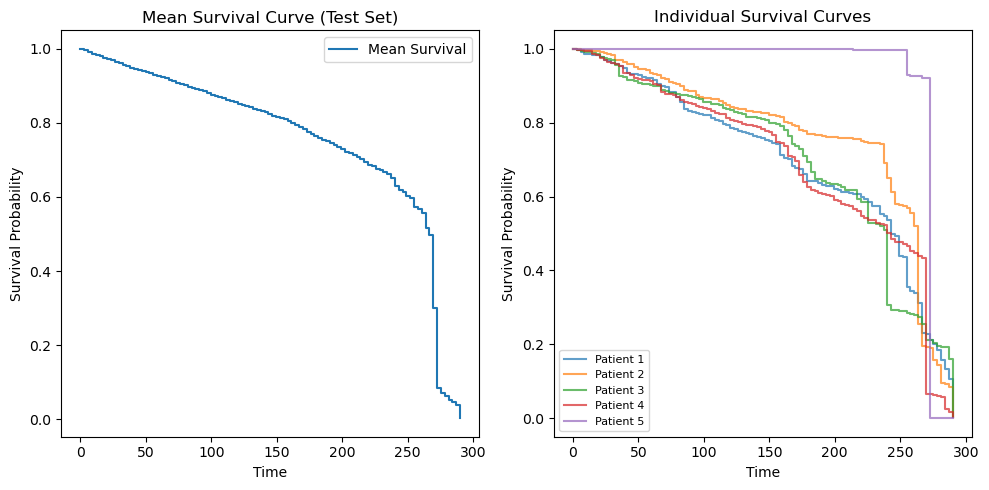

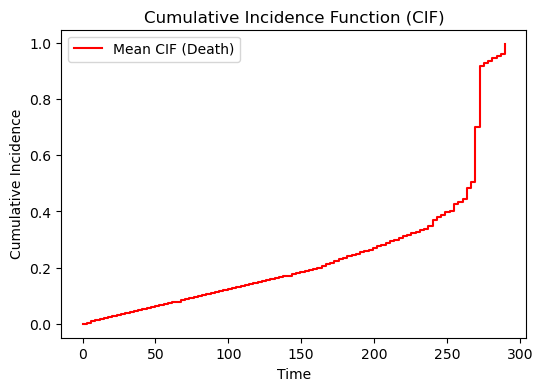


C-index: 0.8748


In [94]:
# ------------------------------
# 1. Load and prepare data
# ------------------------------

# Assume 'T' = duration column, 'E' = event indicator
T_train = df_cardiovascular_train["FU"] 
T_test = df_cardiovascular_test["FU"] 
T_eval = df_cardiovascular_eval["FU"]         
E_train = df_cardiovascular_train["death"]
E_test = df_cardiovascular_test["death"]
E_eval = df_cardiovascular_eval["death"]
X_train = df_cardiovascular_train.drop(columns=["FU", "death"])
X_test = df_cardiovascular_test.drop(columns=["FU", "death"])
X_eval = df_cardiovascular_eval.drop(columns=["FU", "death"])

X_train_np = X_train.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
X_eval_np = X_eval.values.astype('float32')

# ------------------------------
# 2. Define DeepHit network
# ------------------------------

# Choose number of discrete time intervals
num_durations = 100  # can also try 200

labtrans = LabTransDiscreteTime(num_durations)

# Fit and transform train labels
y_train = labtrans.fit_transform(T_train.values, E_train.values) 
y_test = labtrans.transform(T_test.values, E_test.values)
y_eval = labtrans.transform(T_eval.values, E_eval.values)

# Now the number of output nodes = labtrans.out_features
out_features = labtrans.out_features
print("Network output nodes needed:", out_features)

in_features = X_train.shape[1]
num_nodes = [64, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(
    in_features, 
    num_nodes, 
    out_features = out_features ,  # output nodes for discretized times
    batch_norm=True, 
    dropout=dropout, 
    activation=torch.nn.ReLU
)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# Define DeepHit model
model = DeepHitSingle(net, tt.optim.AdamWR, duration_index=labtrans.cuts)  # duration_index will be inferred automatically

# ------------------------------
# 3. Train model
# ------------------------------
epochs = 50
batch_size = 128

log = model.fit(
    X_train_np, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
    val_data = (X_eval_np, y_eval)
)

# ------------------------------
# 4. Predict survival functions
# ------------------------------
surv = model.predict_surv_df(X_test_np)  # returns survival probability over discretized times

# ------------------------------
# 5. Evaluate model
# ------------------------------
# For competing risks, we evaluate CIF for each event type
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')

# Concordance index (overall)
c_index = ev.concordance_td()
print("C-index:", c_index)

# ------------------------------
# 6. Plot survival curves
# ------------------------------
times = surv.index.values

# Option A: Plot mean survival curve across all test patients
mean_surv = surv.mean(axis=1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.step(times, mean_surv, where='post', label='Mean Survival')
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Mean Survival Curve (Test Set)")
plt.legend()

# Option B: Plot a few individual patient survival curves
plt.subplot(1, 2, 2)
for i in range(min(5, surv.shape[1])):  # plot first 5 patients
    plt.step(times, surv.iloc[:, i], where='post', alpha=0.7, label=f"Patient {i+1}")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Individual Survival Curves")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Plot CIF (1 - Survival)
# ------------------------------
plt.figure(figsize=(6, 4))
mean_cif = 1 - mean_surv
plt.step(times, mean_cif, where='post', color='red', label='Mean CIF (Death)')
plt.xlabel("Time")
plt.ylabel("Cumulative Incidence")
plt.title("Cumulative Incidence Function (CIF)")
plt.legend()
plt.show()

print(f"\nC-index: {c_index:.4f}")

## Time to Myocardial Infarction

In [95]:
df_MI = df_value.copy()
df_MI["MI_event"] = df_MI[["NF_IMA","F_IMA"]].max(axis=1)
df_MI["Other events"] = df_MI["STATO_AL_FU"] - df_MI["MI_event"]
df_MI["events"] = 0
df_MI.loc[df_MI["MI_event"] == 1, "events"] = 1
df_MI.loc[df_MI["Other events"] == 1, "events"] = 2

In [96]:
df_MI["events"].value_counts()

events
0    13296
2     2269
1      653
Name: count, dtype: int64

In [97]:
df_MI["FU"] = np.where(
    df_MI["MI_event"] == 1,
    df_MI[["FU_NF_IMA", "FU_F_IMA"]].min(axis=1),
    df_MI["FU"]
)

In [98]:
# Split dataset into train, eval, and test sets
df_MI['time'] = pd.qcut(df_MI['FU'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_MI['stratum'] = df_MI['events'].astype(str) + '_' + df_MI['time'].astype(str)

df_MI_train, df_tmp = train_test_split(
    df_MI, test_size=0.2, random_state=42,
    stratify=df_cardiovascular["stratum"]
)

df_MI_eval, df_MI_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_MI_train, df_MI_eval, df_MI_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)

print(f"Train set: {len(df_MI_train)} samples")
print(f"Eval set: {len(df_MI_eval)} samples")
print(f"Test set: {len(df_MI_test)} samples")

Train set: 12974 samples
Eval set: 1622 samples
Test set: 1622 samples


In [99]:
binary_cols = [
    col for col in df_MI_train.columns
    if set(df_MI[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['SESSO', 'DIABETE', 'STATO_AL_FU', 'NF_IMA', 'F_IMA', 'NF_CBV', 'F_CBV', 'NF_HF', 'MORTE_CV', 'IPERTESO', 'MI_event']


In [100]:
cols_to_keep = binary_cols + ["FU", "events" ]

tmp_train = df_MI_train[cols_to_keep].copy()
tmp_test = df_MI_test[cols_to_keep].copy()
tmp_eval = df_MI_eval[cols_to_keep].copy()

df_MI_train = df_MI_train.drop(columns=cols_to_keep)
df_MI_test = df_MI_test.drop(columns=cols_to_keep)
df_MI_eval = df_MI_eval.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_MI_train)
scaled_array_test = scaler.transform(df_MI_test)
scaled_array_eval = scaler.transform(df_MI_eval)

df_MI_train = pd.DataFrame(scaled_array_train, columns=df_MI_train.columns, index=df_MI_train.index)
df_MI_test = pd.DataFrame(scaled_array_test, columns=df_MI_test.columns, index=df_MI_test.index)
df_MI_eval = pd.DataFrame(scaled_array_eval, columns=df_MI_eval.columns, index=df_MI_eval.index)

df_MI_train = pd.concat([df_MI_train, tmp_train], axis=1)
df_MI_test = pd.concat([df_MI_test, tmp_test], axis=1)
df_MI_eval = pd.concat([df_MI_eval, tmp_eval], axis=1)

cols_to_drop = [ "FU_NF_IMA",
                 "FU_F_IMA",
                 "FU_NF_CBV",
                 "FU_F_CBV",
                 "FU_NF_HF",
                 "FU_F_HF",
                 "NF_IMA",
                 "F_IMA",
                 "NF_CBV",
                 "F_CBV",
                 "NF_HF",
                 "F_HF",
                 "MORTE_CV",
                 "STATO_AL_FU",
                 "MI_event",
                 "Other events"
                ]
df_MI_train = df_MI_train.drop(columns=cols_to_drop)
df_MI_test = df_MI_test.drop(columns=cols_to_drop)
df_MI_eval = df_MI_eval.drop(columns=cols_to_drop)

df_MI_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12974 entries, 20545 to 17062
Data columns (total 49 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ETA             12974 non-null  float64
 1   FAM_IPERT       12974 non-null  float64
 2   FAM_CV          12974 non-null  float64
 3   FUMO_ATT        12974 non-null  float64
 4   EXFUMO          12974 non-null  float64
 5   ALCOOL          12974 non-null  float64
 6   ETANOLO_G_DIE   12974 non-null  float64
 7   ATT_FIS         12974 non-null  float64
 8   ATT_FIS_H_SETT  12974 non-null  float64
 9   IRC             12974 non-null  float64
 10  GOTTA           12974 non-null  float64
 11  ALLOPURINOLO    12974 non-null  float64
 12  PESO            12974 non-null  float64
 13  ALTEZZA         12974 non-null  float64
 14  BMI             12974 non-null  float64
 15  VITA            12974 non-null  float64
 16  PAS             12974 non-null  float64
 17  PAD             12974 non-null  

In [101]:
causes = [1, 2]
models = {}

for cause in causes:
    df_temp = df_MI_train.copy()
    df_temp["events"] = (df_temp["events"] == cause).astype(int)

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        df_temp,
        duration_col="FU",
        event_col='events'
    )
    models[cause] = cph

### Time to stroke

In [102]:
for model in models.values():
    print("Concordance Index:", model.concordance_index_)

Concordance Index: 0.7835979029006139
Concordance Index: 0.8370879729875813


               MI event  Other event    MI event p  Other event p
covariate                                                        
ETA            1.181041     1.466839  5.695870e-11   3.118273e-62
FAM_IPERT      0.978682     0.884174  3.914891e-01   1.288251e-07
FAM_CV         0.977231     0.884724  3.593708e-01   1.320488e-07
FUMO_ATT       1.020930     1.059055  3.908059e-01   2.496156e-03
EXFUMO         1.018848     1.078336  4.457822e-01   2.792171e-04
ETANOLO_G_DIE  1.032384     1.073816  1.907899e-01   4.936717e-04
IRC            1.011453     1.073194  6.380802e-01   6.886468e-04
GOTTA          1.024090     0.947462  3.407993e-01   1.736767e-02
ALLOPURINOLO   1.095412     1.146557  2.363290e-04   9.138059e-10
PESO           0.974043     0.952842  2.937915e-01   3.404141e-02
ALTEZZA        0.976910     0.939760  3.499639e-01   4.811411e-03
PAS            1.059242     1.068867  1.861137e-02   1.115553e-03
FC             1.022273     1.082581  3.526722e-01   2.210749e-05
CREATININA

<Axes: xlabel='covariate'>

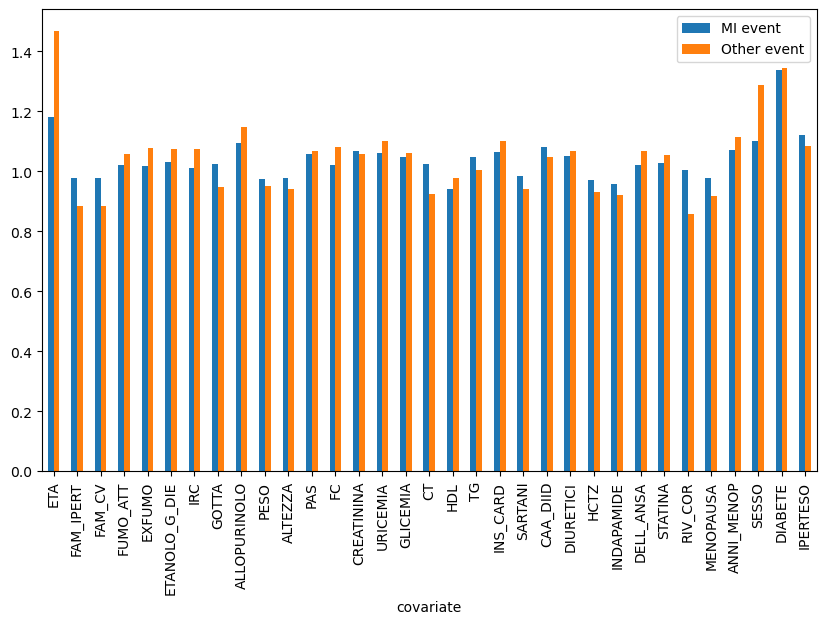

In [103]:
coef_MI = models[1].summary["exp(coef)"]
coef_other = models[2].summary["exp(coef)"]
p_MI = models[1].summary["p"]
p_other = models[2].summary["p"]

significant = (
    (p_MI < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "MI event": coef_MI,
    "Other event": coef_other,
    "MI event p": p_MI,
    "Other event p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["MI event","Other event"]].plot.bar(figsize=(10,6))

Network output nodes needed: 100
0:	[0s / 0s],		train_loss: 0.3758,	val_loss: 0.3687
1:	[0s / 1s],		train_loss: 0.3407,	val_loss: 0.3255
2:	[0s / 1s],		train_loss: 0.3170,	val_loss: 0.3199
3:	[0s / 1s],		train_loss: 0.3046,	val_loss: 0.3029
4:	[0s / 2s],		train_loss: 0.2906,	val_loss: 0.2974
5:	[0s / 2s],		train_loss: 0.2843,	val_loss: 0.2944
6:	[0s / 3s],		train_loss: 0.2842,	val_loss: 0.2932
7:	[0s / 3s],		train_loss: 0.2832,	val_loss: 0.2916
8:	[0s / 3s],		train_loss: 0.2783,	val_loss: 0.2899
9:	[0s / 4s],		train_loss: 0.2760,	val_loss: 0.2895
10:	[0s / 4s],		train_loss: 0.2749,	val_loss: 0.2899
11:	[0s / 5s],		train_loss: 0.2707,	val_loss: 0.2894
12:	[0s / 5s],		train_loss: 0.2705,	val_loss: 0.2896
13:	[0s / 5s],		train_loss: 0.2701,	val_loss: 0.2894
14:	[0s / 6s],		train_loss: 0.2683,	val_loss: 0.2896
15:	[0s / 6s],		train_loss: 0.2693,	val_loss: 0.2894
16:	[0s / 7s],		train_loss: 0.2686,	val_loss: 0.2909
17:	[0s / 7s],		train_loss: 0.2675,	val_loss: 0.2896
18:	[0s / 7s],		train_l

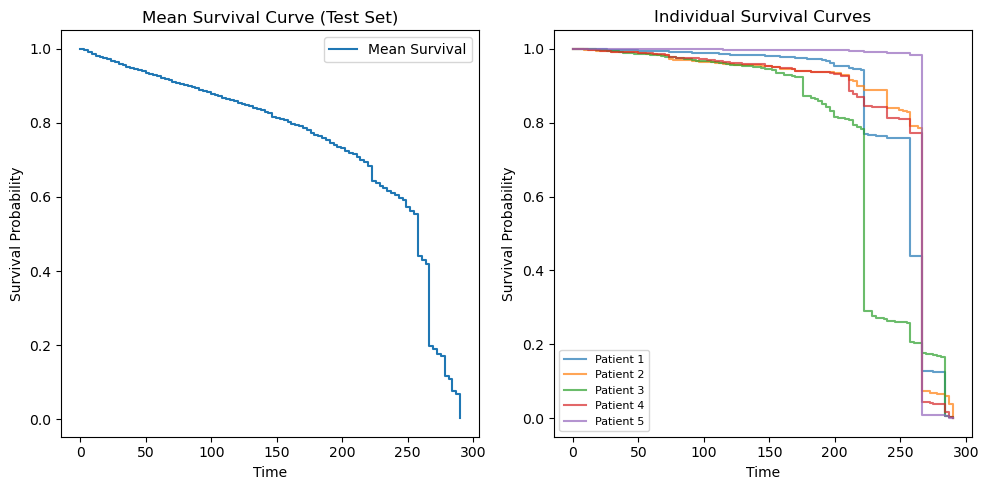

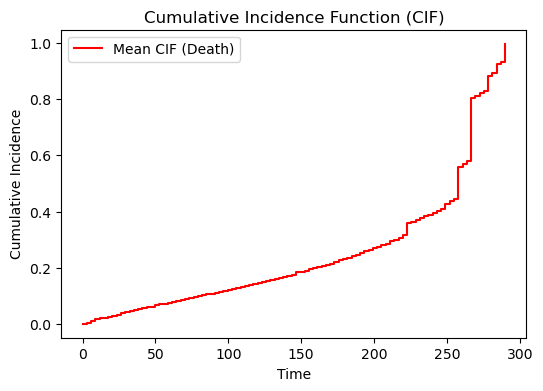


C-index: 0.8441


In [104]:
# ------------------------------
# 1. Load and prepare data
# ------------------------------

# Assume 'T' = duration column, 'E' = event indicator
T_train = df_MI_train["FU"]  
T_test = df_MI_test["FU"]  
T_eval = df_MI_eval["FU"]         
E_train = df_MI_train["events"]
E_test = df_MI_test["events"]
E_eval = df_MI_eval["events"]
X_train = df_MI_train.drop(columns=["FU", "events"])
X_test = df_MI_test.drop(columns=["FU", "events"])
X_eval = df_MI_eval.drop(columns=["FU", "events"]) 

X_train_np = X_train.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
X_eval_np  = X_eval.values.astype('float32')
 
# ------------------------------
# 2. Define DeepHit network
# ------------------------------

# Choose number of discrete time intervals
num_durations = 100  # can also try 200

labtrans = LabTransDiscreteTime(num_durations)

# Fit and transform train labels
y_train = labtrans.fit_transform(T_train.values, E_train.values) 
y_test = labtrans.transform(T_test.values, E_test.values)
y_eval = labtrans.transform(T_eval.values, E_eval.values)

# Now the number of output nodes = labtrans.out_features
out_features = labtrans.out_features
print("Network output nodes needed:", out_features)

in_features = X_train.shape[1]
num_nodes = [64, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(
    in_features, 
    num_nodes, 
    out_features = out_features ,  # output nodes for discretized times
    batch_norm=True, 
    dropout=dropout, 
    activation=torch.nn.ReLU
)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# Define DeepHit model
model = DeepHitSingle(net, tt.optim.AdamWR, duration_index=labtrans.cuts)  # duration_index will be inferred automatically

# ------------------------------
# 3. Train model
# ------------------------------
epochs = 50
batch_size = 128

log = model.fit(
    X_train_np, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
    val_data= (X_eval_np, y_eval )
)

# ------------------------------
# 4. Predict survival functions
# ------------------------------
surv = model.predict_surv_df(X_test_np)  # returns survival probability over discretized times

# ------------------------------
# 5. Evaluate model
# ------------------------------
# For competing risks, we evaluate CIF for each event type
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')

# Concordance index (overall)
c_index = ev.concordance_td()
print("C-index:", c_index)

# ------------------------------
# 6. Plot survival curves
# ------------------------------
times = surv.index.values

# Option A: Plot mean survival curve across all test patients
mean_surv = surv.mean(axis=1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.step(times, mean_surv, where='post', label='Mean Survival')
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Mean Survival Curve (Test Set)")
plt.legend()

# Option B: Plot a few individual patient survival curves
plt.subplot(1, 2, 2)
for i in range(min(5, surv.shape[1])):  # plot first 5 patients
    plt.step(times, surv.iloc[:, i], where='post', alpha=0.7, label=f"Patient {i+1}")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Individual Survival Curves")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Plot CIF (1 - Survival)
# ------------------------------
plt.figure(figsize=(6, 4))
mean_cif = 1 - mean_surv
plt.step(times, mean_cif, where='post', color='red', label='Mean CIF (Death)')
plt.xlabel("Time")
plt.ylabel("Cumulative Incidence")
plt.title("Cumulative Incidence Function (CIF)")
plt.legend()
plt.show()

print(f"\nC-index: {c_index:.4f}")

### Time to stroke

In [105]:
df_stroke = df_value.copy()
df_stroke["events"] = 0
df_stroke.loc[df_stroke["NF_CBV"] == 1, "events"] = 1
df_stroke.loc[df_stroke["F_CBV"] == 1, "events"] = 1
df_stroke.loc[df_stroke["STATO_AL_FU"] == 1, "events"] = 2

In [106]:
df_stroke["FU"] = np.where(
    df_stroke["NF_CBV"] == 1,
    df_stroke["FU_NF_CBV"],
    np.where(
        df_stroke["F_CBV"] == 1,
        df_stroke["FU_F_CBV"],
        df_stroke["FU"]
    )
)

In [107]:
# Split dataset into train, eval, and test sets

df_stroke['time'] = pd.qcut(df_stroke['FU'], q=4, labels=False, duplicates='drop')

# 2. Crea la variabile di stratificazione combinata
#    Es: evento=1, bin=2 → stratum "1_2"
df_stroke['stratum'] = df_stroke['events'].astype(str) + '_' + df_stroke['time'].astype(str)

df_stroke_train, df_tmp = train_test_split(
    df_stroke, test_size=0.3, random_state=42,
    stratify=df_stroke["stratum"]
)

df_stroke_eval, df_stroke_test = train_test_split(
    df_tmp, test_size=0.5, random_state=42,
    stratify=df_tmp["stratum"]
)

for split in [df_stroke_train, df_stroke_eval, df_stroke_test]:
    split.drop(columns=['time', 'stratum'], inplace=True)

print(f"Train set: {len(df_stroke_train)} samples")
print(f"Eval set: {len(df_stroke_eval)} samples")
print(f"Test set: {len(df_stroke_test)} samples")



Train set: 11352 samples
Eval set: 2433 samples
Test set: 2433 samples


In [108]:
binary_cols = [
    col for col in df_stroke_train.columns
    if set(df_stroke_train[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['SESSO', 'DIABETE', 'STATO_AL_FU', 'NF_IMA', 'F_IMA', 'NF_CBV', 'F_CBV', 'NF_HF', 'MORTE_CV', 'IPERTESO']


In [109]:
cols_to_keep = binary_cols + ["FU","events"]

tmp_train = df_stroke_train[cols_to_keep].copy()
tmp_test = df_stroke_test[cols_to_keep].copy()
tmp_eval = df_stroke_eval[cols_to_keep].copy()

df_stroke_train = df_stroke_train.drop(columns=cols_to_keep)
df_stroke_test = df_stroke_test.drop(columns=cols_to_keep)
df_stroke_eval = df_stroke_eval.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array_train = scaler.fit_transform(df_stroke_train)
scaled_array_test = scaler.transform(df_stroke_test)
scaled_array_eval = scaler.transform(df_stroke_eval)

df_stroke_train = pd.DataFrame(scaled_array_train, columns=df_stroke_train.columns, index=df_stroke_train.index)
df_stroke_test = pd.DataFrame(scaled_array_test, columns=df_stroke_test.columns, index=df_stroke_test.index)
df_stroke_eval = pd.DataFrame(scaled_array_eval, columns=df_stroke_eval.columns, index=df_stroke_eval.index)

df_stroke_train = pd.concat([df_stroke_train, tmp_train], axis=1)
df_stroke_test = pd.concat([df_stroke_test, tmp_test], axis=1)
df_stroke_eval = pd.concat([df_stroke_eval, tmp_eval], axis=1)

cols_to_drop = [ "FU_NF_IMA",
                 "FU_F_IMA",
                 "FU_NF_CBV",
                 "FU_F_CBV",
                 "FU_NF_HF",
                 "FU_F_HF",
                 "NF_IMA",
                 "F_IMA",
                 "NF_CBV",
                 "F_CBV",
                 "NF_HF",
                 "F_HF",
                 "MORTE_CV",
                 "STATO_AL_FU",
                ]

df_stroke_train = df_stroke_train.drop(columns=cols_to_drop)
df_stroke_test = df_stroke_test.drop(columns=cols_to_drop)
df_stroke_eval = df_stroke_eval.drop(columns=cols_to_drop)

print(df_stroke_train.info())
print(df_stroke_train["events"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 11352 entries, 2783 to 8908
Data columns (total 49 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ETA             11352 non-null  float64
 1   FAM_IPERT       11352 non-null  float64
 2   FAM_CV          11352 non-null  float64
 3   FUMO_ATT        11352 non-null  float64
 4   EXFUMO          11352 non-null  float64
 5   ALCOOL          11352 non-null  float64
 6   ETANOLO_G_DIE   11352 non-null  float64
 7   ATT_FIS         11352 non-null  float64
 8   ATT_FIS_H_SETT  11352 non-null  float64
 9   IRC             11352 non-null  float64
 10  GOTTA           11352 non-null  float64
 11  ALLOPURINOLO    11352 non-null  float64
 12  PESO            11352 non-null  float64
 13  ALTEZZA         11352 non-null  float64
 14  BMI             11352 non-null  float64
 15  VITA            11352 non-null  float64
 16  PAS             11352 non-null  float64
 17  PAD             11352 non-null  fl

In [110]:
causes = [1, 2]
models = {}

for cause in causes:
    df_temp = df_stroke_train.copy()
    df_temp["events"] = (df_temp["events"] == cause).astype(int)

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        df_temp,
        duration_col="FU",
        event_col='events'
    )
    models[cause] = cph

In [111]:
for model in models.values():
    print("Concordance Index:", model.concordance_index_)

Concordance Index: 0.7401483240745396
Concordance Index: 0.8362793178579541


                Stroke event  Other event  Stroke event p  Other event p
covariate                                                               
ETA                 1.036387     1.510828        0.209781   6.760324e-66
FAM_IPERT           1.018411     0.874891        0.520654   4.397921e-08
FAM_CV              1.007389     0.905491        0.794811   4.191026e-05
FUMO_ATT            0.989212     1.065086        0.696383   1.255094e-03
EXFUMO              1.017693     1.090059        0.532913   4.713808e-05
ETANOLO_G_DIE       1.016793     1.080673        0.555162   1.749311e-04
ATT_FIS_H_SETT      1.012433     0.940761        0.660085   8.180355e-03
IRC                 1.011632     1.057208        0.680855   9.987453e-03
GOTTA               0.989931     0.930841        0.720033   2.487384e-03
ALLOPURINOLO        1.007336     1.184056        0.795640   2.940607e-13
PESO                1.008414     0.943192        0.767849   1.469061e-02
ALTEZZA             0.985210     0.945372        0.

<Axes: xlabel='covariate'>

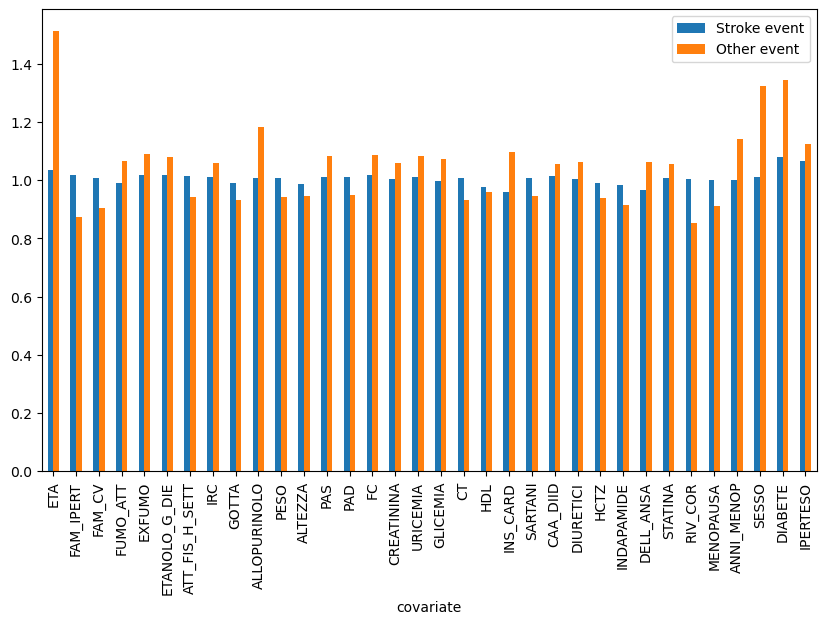

In [112]:
coef_stroke = models[1].summary["exp(coef)"]
coef_other = models[2].summary["exp(coef)"]
p_stroke = models[1].summary["p"]
p_other = models[2].summary["p"]

significant = (
    (p_stroke < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "Stroke event": coef_stroke,
    "Other event": coef_other,
    "Stroke event p": p_stroke,
    "Other event p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["Stroke event","Other event"]].plot.bar(figsize=(10,6))

Network output nodes needed: 100
0:	[0s / 0s],		train_loss: 0.3758,	val_loss: 0.3589
1:	[0s / 0s],		train_loss: 0.3432,	val_loss: 0.3246
2:	[0s / 1s],		train_loss: 0.3206,	val_loss: 0.3196
3:	[0s / 1s],		train_loss: 0.3076,	val_loss: 0.3003
4:	[0s / 2s],		train_loss: 0.2927,	val_loss: 0.2915
5:	[0s / 2s],		train_loss: 0.2868,	val_loss: 0.2889
6:	[0s / 3s],		train_loss: 0.2851,	val_loss: 0.2893
7:	[0s / 3s],		train_loss: 0.2824,	val_loss: 0.2863
8:	[0s / 3s],		train_loss: 0.2793,	val_loss: 0.2842
9:	[0s / 4s],		train_loss: 0.2769,	val_loss: 0.2831
10:	[0s / 4s],		train_loss: 0.2735,	val_loss: 0.2811
11:	[0s / 5s],		train_loss: 0.2699,	val_loss: 0.2810
12:	[0s / 5s],		train_loss: 0.2704,	val_loss: 0.2811
13:	[0s / 6s],		train_loss: 0.2694,	val_loss: 0.2809
14:	[0s / 6s],		train_loss: 0.2689,	val_loss: 0.2809
15:	[0s / 7s],		train_loss: 0.2740,	val_loss: 0.2801
16:	[0s / 7s],		train_loss: 0.2703,	val_loss: 0.2800
17:	[0s / 7s],		train_loss: 0.2683,	val_loss: 0.2802
18:	[0s / 8s],		train_l

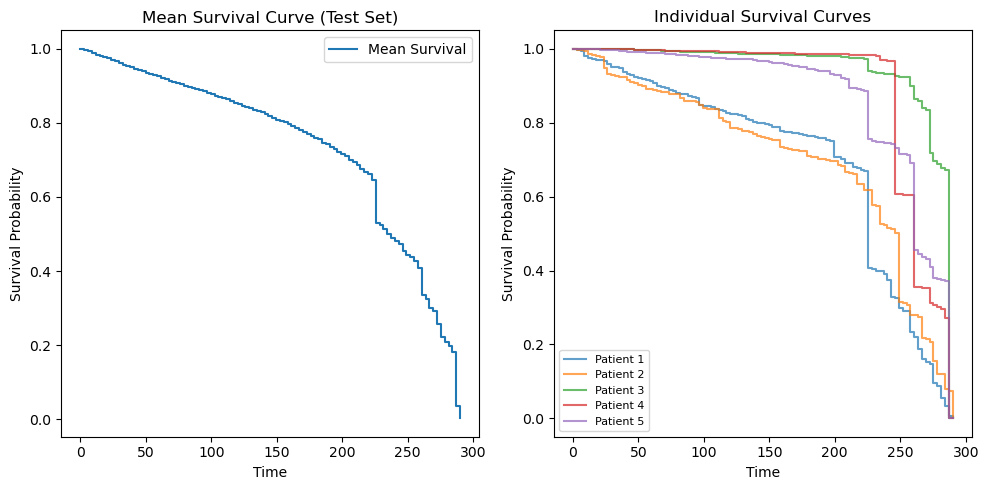

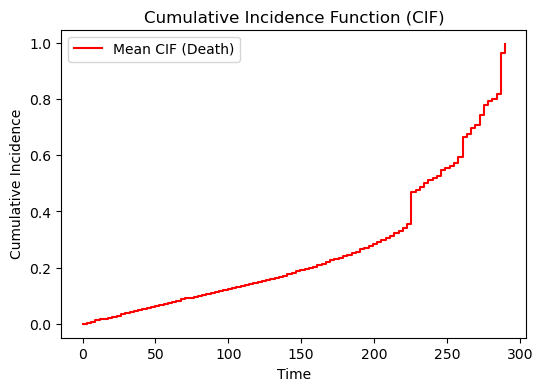


C-index: 0.6701


In [113]:
# ------------------------------
# 1. Load and prepare data
# ------------------------------

# Assume 'T' = duration column, 'E' = event indicator
T_train = df_stroke_train["FU"]         
T_test = df_stroke_test["FU"]         
T_eval = df_stroke_eval["FU"]         
E_train = df_stroke_train["events"]
E_test = df_stroke_test["events"]
E_eval = df_stroke_eval["events"]
X_train = df_stroke_train.drop(columns=["FU", "events"]) 
X_test = df_stroke_test.drop(columns=["FU", "events"]) 
X_eval = df_stroke_eval.drop(columns=["FU", "events"]) 

X_train_np = X_train.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
X_eval_np  = X_eval.values.astype('float32')

# ------------------------------
# 2. Define DeepHit network
# ------------------------------

# Choose number of discrete time intervals
num_durations = 100  # can also try 200

labtrans = LabTransDiscreteTime(num_durations)

# Fit and transform train labels
y_train = labtrans.fit_transform(T_train.values, E_train.values) 
y_test = labtrans.transform(T_test.values, E_test.values)
y_eval = labtrans.transform(T_eval.values, E_eval.values)

# Now the number of output nodes = labtrans.out_features
out_features = labtrans.out_features
print("Network output nodes needed:", out_features)

in_features = X_train.shape[1]
num_nodes = [64, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(
    in_features, 
    num_nodes, 
    out_features = out_features ,  # output nodes for discretized times
    batch_norm=True, 
    dropout=dropout, 
    activation=torch.nn.ReLU
)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# Define DeepHit model
model = DeepHitSingle(net, tt.optim.AdamWR, duration_index=labtrans.cuts)  # duration_index will be inferred automatically

# ------------------------------
# 3. Train model
# ------------------------------
epochs = 50
batch_size = 128

log = model.fit(
    X_train_np, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
    val_data=(X_eval_np, y_eval)
)

# ------------------------------
# 4. Predict survival functions
# ------------------------------
surv = model.predict_surv_df(X_test_np)  # returns survival probability over discretized times

# ------------------------------
# 5. Evaluate model
# ------------------------------
# For competing risks, we evaluate CIF for each event type
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')

# Concordance index (overall)
c_index = ev.concordance_td()
print("C-index:", c_index)

# ------------------------------
# 6. Plot survival curves
# ------------------------------
times = surv.index.values

# Option A: Plot mean survival curve across all test patients
mean_surv = surv.mean(axis=1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.step(times, mean_surv, where='post', label='Mean Survival')
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Mean Survival Curve (Test Set)")
plt.legend()

# Option B: Plot a few individual patient survival curves
plt.subplot(1, 2, 2)
for i in range(min(5, surv.shape[1])):  # plot first 5 patients
    plt.step(times, surv.iloc[:, i], where='post', alpha=0.7, label=f"Patient {i+1}")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Individual Survival Curves")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Plot CIF (1 - Survival)
# ------------------------------
plt.figure(figsize=(6, 4))
mean_cif = 1 - mean_surv
plt.step(times, mean_cif, where='post', color='red', label='Mean CIF (Death)')
plt.xlabel("Time")
plt.ylabel("Cumulative Incidence")
plt.title("Cumulative Incidence Function (CIF)")
plt.legend()
plt.show()

print(f"\nC-index: {c_index:.4f}")